In [43]:
import pandas as pd
import numpy as np
import time
import heapq
import itertools
import random
import matplotlib.pyplot as plt
from collections import deque

#**Part 4**

##**1. Sample Dataset 1**

In [44]:
from google.colab import drive
drive.mount('/content/drive')

df_1 = pd.read_csv("/content/drive/MyDrive/Sample Datasets-2 data job posts.csv")
print(df_1.columns.tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['jobpost', 'date', 'Title', 'Company', 'AnnouncementCode', 'Term', 'Eligibility', 'Audience', 'StartDate', 'Duration', 'Location', 'JobDescription', 'JobRequirment', 'RequiredQual', 'Salary', 'ApplicationP', 'OpeningDate', 'Deadline', 'Notes', 'AboutC', 'Attach', 'Year', 'Month', 'IT']


In [45]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19001 entries, 0 to 19000
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   jobpost           19001 non-null  object
 1   date              19001 non-null  object
 2   Title             18973 non-null  object
 3   Company           18994 non-null  object
 4   AnnouncementCode  1208 non-null   object
 5   Term              7676 non-null   object
 6   Eligibility       4930 non-null   object
 7   Audience          640 non-null    object
 8   StartDate         9675 non-null   object
 9   Duration          10798 non-null  object
 10  Location          18969 non-null  object
 11  JobDescription    15109 non-null  object
 12  JobRequirment     16479 non-null  object
 13  RequiredQual      18517 non-null  object
 14  Salary            9622 non-null   object
 15  ApplicationP      18941 non-null  object
 16  OpeningDate       18295 non-null  object
 17  Deadline    

###**a. Load & Prepare Sample Dataset 1**

In [46]:
import re
import numpy as np
import pandas as pd

# =========================
# 1. LOAD + PREPARE DATASET 1
# =========================

def parse_bool_flag(value):
    """
    Safely parse boolean-like values from mixed raw inputs.
    Prevents issues such as astype(bool) turning non-empty strings
    like 'False' into True.
    """
    if pd.isna(value):
        return False

    text = str(value).strip().lower()

    true_values = {"true", "1", "yes", "y", "t"}
    false_values = {"false", "0", "no", "n", "f", "", "nan", "none"}

    if text in true_values:
        return True
    if text in false_values:
        return False

    return False


def extract_salary_value(text):
    """
    Extract a salary proxy and convert it to an annual salary estimate where possible.

    Logic:
    - Require at least one salary-like hint OR a clear numeric amount
    - Extract all numeric chunks
    - Remove absurd values
    - If a range exists, use midpoint
    - Detect salary period:
        * hourly -> value * 40 * 52
        * monthly -> value * 12
        * yearly/annual -> keep as is
    - If no period is clear:
        * large values are treated as annual
        * moderate values may be monthly and are converted conservatively
    """
    if pd.isna(text):
        return np.nan

    text = str(text).strip().lower()
    if text == "":
        return np.nan

    salary_hints = [
        "$", "usd", "salary", "month", "monthly", "annual", "annum",
        "year", "yearly", "hour", "hourly", "per hour", "per month", "per year"
    ]

    # Extract numeric chunks
    matches = re.findall(r"\d[\d,]*\.?\d*", text)
    if not matches:
        return np.nan

    values = []
    for m in matches:
        try:
            v = float(m.replace(",", ""))
            values.append(v)
        except Exception:
            continue

    if not values:
        return np.nan

    # Keep only realistic raw values before conversion
    reasonable = [v for v in values if 10 <= v <= 1_000_000]
    if not reasonable:
        return np.nan

    # If there is no salary hint and numbers are tiny/ambiguous, reject
    has_salary_hint = any(hint in text for hint in salary_hints)
    if not has_salary_hint and max(reasonable) < 1000:
        return np.nan

    # Range -> midpoint, otherwise first reasonable value
    if len(reasonable) >= 2:
        base_value = (reasonable[0] + reasonable[1]) / 2
    else:
        base_value = reasonable[0]

    # Detect time unit
    is_hourly = bool(re.search(r"\bhour\b|\bhourly\b|per hour|/hr|\bhr\b", text))
    is_monthly = bool(re.search(r"\bmonth\b|\bmonthly\b|per month|/mo\b", text))
    is_yearly = bool(re.search(r"\byear\b|\byearly\b|\bannual\b|\bannum\b|per year|/yr\b", text))

    # Convert to annual proxy
    if is_hourly:
        annual_value = base_value * 40 * 52
    elif is_monthly:
        annual_value = base_value * 12
    elif is_yearly:
        annual_value = base_value
    else:
        # Conservative fallback:
        # - if already large enough, likely annual
        # - if moderate, possibly monthly
        # - if too small, likely hourly/unclear -> reject
        if base_value >= 15_000:
            annual_value = base_value
        elif 1_000 <= base_value < 15_000:
            annual_value = base_value * 12
        else:
            return np.nan

    # Final sanity range for annual proxy
    if annual_value < 10_000 or annual_value > 1_000_000:
        return np.nan

    return round(annual_value, 2)


def load_and_prepare_dataset_1(file_path):
    cols = [
        "Title",
        "Location",
        "Salary",
        "Eligibility",
        "Term",
        "IT"
    ]

    df_1 = pd.read_csv(file_path, usecols=cols)
    jobs = df_1.copy()

    # Rename to align with dataset 2 schema
    jobs = jobs.rename(columns={
        "Title": "title",
        "Location": "location",
        "Salary": "salary_raw",
        "Eligibility": "formatted_experience_level",
        "Term": "formatted_work_type",
        "IT": "it_flag"
    })

    # -------------------------
    # Clean text columns
    # -------------------------
    for col in ["title", "location", "formatted_work_type"]:
        jobs[col] = (
            jobs[col]
            .fillna("")
            .astype(str)
            .str.strip()
        )

    jobs["formatted_experience_level"] = (
        jobs["formatted_experience_level"]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .replace("", "Unknown")
    )

    # Optional normalized lowercase helper columns
    jobs["title_clean"] = jobs["title"].str.lower()
    jobs["location_clean"] = jobs["location"].str.lower()
    jobs["work_type_clean"] = jobs["formatted_work_type"].str.lower()
    jobs["experience_clean"] = jobs["formatted_experience_level"].str.lower()

    # -------------------------
    # Clean IT flag safely
    # -------------------------
    if "it_flag" in jobs.columns:
        jobs["it_flag"] = jobs["it_flag"].apply(parse_bool_flag)
    else:
        jobs["it_flag"] = False

    # -------------------------
    # Clean salary into annual proxy
    # -------------------------
    jobs["salary_final"] = jobs["salary_raw"].apply(extract_salary_value)

    # Final salary sanity check
    jobs.loc[
        (jobs["salary_final"] < 10_000) | (jobs["salary_final"] > 1_000_000),
        "salary_final"
    ] = np.nan

    # -------------------------
    # AI / tech title flag
    # -------------------------
    ai_tech_pattern = (
        r"\bai\b|"
        r"artificial intelligen\w*|"
        r"machine learning|"
        r"\bml\b|"
        r"\bnlp\b|"
        r"natural language processing|"
        r"computer vision|"
        r"deep learning|"
        r"data scientist|"
        r"data science|"
        r"data analyst|"
        r"data engineer|"
        r"software engineer|"
        r"software developer|"
        r"business intelligence|"
        r"\bbi\b"
    )

    jobs["ai_title_flag"] = (
        jobs["title"].str.contains(ai_tech_pattern, case=False, na=False, regex=True)
        | jobs["it_flag"]
    )

    return jobs


# Example load
file_path_1 = "/content/drive/MyDrive/Sample Datasets-2 data job posts.csv"
jobs_1 = load_and_prepare_dataset_1(file_path_1)

print("Shape:", jobs_1.shape)
print("AI/tech jobs found:", jobs_1["ai_title_flag"].sum())
print("Missing salary_final:", jobs_1["salary_final"].isna().sum())
print("Missing work_type:", (jobs_1["formatted_work_type"] == "").sum())
print("Missing experience:", (jobs_1["formatted_experience_level"] == "Unknown").sum())

print("\nSalary summary after cleaning (annual proxy):")
display(jobs_1["salary_final"].describe())

print("\nTop suspicious raw salary rows:")
display(
    jobs_1.loc[jobs_1["salary_final"].notna(), ["title", "salary_raw", "salary_final"]]
    .sort_values("salary_final", ascending=False)
    .head()
)

Shape: (19001, 12)
AI/tech jobs found: 3786
Missing salary_final: 18075
Missing work_type: 11325
Missing experience: 14071

Salary summary after cleaning (annual proxy):


,salary_final
count,926.000000
mean,228593.657127
std,218415.607772
min,10200.000000
25%,100000.000000
50%,127000.000000
75%,300000.000000
max,1000000.000000



Top suspicious raw salary rows:


,title,salary_raw,salary_final
17868,Senior SW Engineer,"1,000,000 AMD and higher.",1000000.0
17866,Senior SW Engineer,"1,000,000 AMD and higher.",1000000.0
10838,Construction Project Manager,"1,000,000 AMD plus a comprehensive benefits\r\...",1000000.0
8719,Business Development Director,"starting from AMD 1,000,000",1000000.0
18508,Logistics Manager,"1,000,000 AMD",1000000.0


###**b. Shared Action Library**

In [47]:
# =========================
# 2. SHARED ACTION LIBRARY
# =========================
def build_action_library_dataset_1(df_reference=None):
    """
    Build a shared action library aligned with prepared features.

    Action groups:
    A. Relevance filters
    B. Data quality / completeness filters
    C. Work type preference filters
    D. Experience preference filters
    E. Salary preference filters
    """
    actions = {}

    # -------------------------
    # A. Relevance filters
    # -------------------------
    actions["filter_ai_related"] = lambda x: x[x["ai_title_flag"] == True]

    # -------------------------
    # B. Data quality / completeness filters
    # -------------------------
    actions["filter_salary_available"] = lambda x: x[x["salary_final"].notna()]
    actions["filter_experience_available"] = lambda x: x[x["formatted_experience_level"] != "Unknown"]
    actions["filter_location_available"] = lambda x: x[x["location"].str.len() > 0]
    actions["filter_work_type_available"] = lambda x: x[x["formatted_work_type"].str.len() > 0]

    # -------------------------
    # C. Work type preference filters
    # -------------------------
    work_type_values = {
        "full_time": r"\bfull[-\s]?time\b",
        "part_time": r"\bpart[-\s]?time\b",
        "contract": r"\bcontract\b",
        "temporary": r"\btemporary\b|\btemp\b",
        "internship": r"\bintern(?:ship)?\b|\btrainee\b"
    }

    for key, pattern in work_type_values.items():
        actions[f"filter_work_type_{key}"] = (
            lambda x, p=pattern: x[
                x["formatted_work_type"].str.contains(p, case=False, na=False, regex=True)
            ]
        )

    # -------------------------
    # D. Experience preference filters
    # -------------------------
    exp_values = {
        "entry": r"\bentry\b|\bjunior\b|\bgraduate\b|\btrainee\b",
        "student": r"\bstudent\b|\bintern(?:ship)?\b",
        "graduate": r"\bgraduate\b",
        "professional": r"\bprofessional\b|\bmid\b|\bassociate\b|\bexperienced\b",
        "manager": r"\bmanager\b|\bmanagement\b",
        "senior": r"\bsenior\b|\blead\b|\bprincipal\b"
    }

    for key, pattern in exp_values.items():
        actions[f"filter_experience_{key}"] = (
            lambda x, p=pattern: x[
                x["formatted_experience_level"].str.contains(p, case=False, na=False, regex=True)
            ]
        )

    # -------------------------
    # E. Salary preference filters
    # -------------------------
    if df_reference is not None and "salary_final" in df_reference.columns:
        valid_salary = df_reference["salary_final"].dropna()

        if len(valid_salary) > 0:
            median_salary = valid_salary.median()
            q75_salary = valid_salary.quantile(0.75)

            actions["filter_salary_above_median"] = (
                lambda x, cutoff=median_salary: x[x["salary_final"].notna() & (x["salary_final"] >= cutoff)]
            )

            actions["filter_salary_top_quartile"] = (
                lambda x, cutoff=q75_salary: x[x["salary_final"].notna() & (x["salary_final"] >= cutoff)]
            )

    return actions


actions_1 = build_action_library_dataset_1(jobs_1)
action_names_1 = list(actions_1.keys())

print("Number of actions:", len(action_names_1))
display(action_names_1)


Number of actions: 18


['filter_ai_related',
 'filter_salary_available',
 'filter_experience_available',
 'filter_location_available',
 'filter_work_type_available',
 'filter_work_type_full_time',
 'filter_work_type_part_time',
 'filter_work_type_contract',
 'filter_work_type_temporary',
 'filter_work_type_internship',
 'filter_experience_entry',
 'filter_experience_student',
 'filter_experience_graduate',
 'filter_experience_professional',
 'filter_experience_manager',
 'filter_experience_senior',
 'filter_salary_above_median',
 'filter_salary_top_quartile']

###**c. Goal State & Common Helpers**

In [48]:
import time
import random
import heapq
import numpy as np
import pandas as pd
from collections import deque

# =========================
# 3. GOAL STATE + COMMON HELPERS
# =========================
def build_ranking_context(df_reference):
    """
    Build dataset-specific context for ranking and fitness.
    This removes the need for a fixed salary cap by using
    salary percentiles from the current dataset.
    """
    valid_salary = df_reference["salary_final"].dropna()

    if len(valid_salary) == 0:
        salary_p25 = 0.0
        salary_p50 = 0.0
        salary_p90 = 1.0
    else:
        salary_p25 = valid_salary.quantile(0.25)
        salary_p50 = valid_salary.quantile(0.50)
        salary_p90 = valid_salary.quantile(0.90)

        if salary_p90 == salary_p25:
            salary_p90 = salary_p25 + 1.0

    return {
        "dataset_size": len(df_reference),
        "salary_p25": float(salary_p25),
        "salary_p50": float(salary_p50),
        "salary_p90": float(salary_p90)
    }


def compute_ranking_quality(df_result, applied_actions, ranking_context):
    """
    Compute ranking quality without a fixed salary cap.
    Salary is scaled relative to the dataset salary distribution.

    Logic:
    - must include AI-related filtering
    - reward:
        * stronger salary level
        * salary availability
        * experience availability
        * location availability
        * full-time preference
        * focused subsets
        * slightly richer action combinations
    """
    n = len(df_result)

    if n == 0:
        return 0.0

    if "filter_ai_related" not in applied_actions:
        return 0.0

    avg_salary = df_result["salary_final"].mean()
    if pd.isna(avg_salary):
        avg_salary_score = 0.0
    else:
        p25 = ranking_context["salary_p25"]
        p90 = ranking_context["salary_p90"]
        avg_salary_score = (avg_salary - p25) / (p90 - p25)
        avg_salary_score = float(np.clip(avg_salary_score, 0.0, 1.0))

    salary_available_score = df_result["salary_final"].notna().mean()
    experience_score = (df_result["formatted_experience_level"] != "Unknown").mean()
    location_score = (df_result["location"].str.len() > 0).mean()

    fulltime_score = df_result["formatted_work_type"].str.contains(
        r"\bfull[-\s]?time\b|\bfull\b",
        case=False,
        na=False,
        regex=True
    ).mean()

    # Smooth focus score (no hard size cap in ranking)
    focus_score = 1.0 / (1.0 + np.log1p(n))
    focus_score = float(np.clip(focus_score * 3.0, 0.0, 1.0))

    # Slight reward for richer filtering
    action_diversity_score = min(len(applied_actions) / 6.0, 1.0)

    score = (
        0.26 * avg_salary_score +
        0.18 * salary_available_score +
        0.15 * fulltime_score +
        0.15 * experience_score +
        0.10 * location_score +
        0.10 * focus_score +
        0.06 * action_diversity_score
    ) * 100

    return round(score, 4)


def is_goal_state(df, applied_actions, min_actions_required=2):
    """
    A state is a goal candidate if:
    - it is not empty
    - AI-related filtering has been applied
    - it is not too trivial
    """
    n = len(df)

    if n == 0:
        return False

    if "filter_ai_related" not in applied_actions:
        return False

    if len(applied_actions) < min_actions_required:
        return False

    return True


def evaluate_goal_state(df_result, applied_actions, depth, ranking_context):
    """
    Compute all evaluation fields for a goal state.
    """
    avg_salary = (
        df_result["salary_final"].mean()
        if df_result["salary_final"].notna().any()
        else np.nan
    )

    ranking_quality = compute_ranking_quality(
        df_result,
        applied_actions,
        ranking_context
    )

    return {
        "applied_actions": applied_actions.copy(),
        "depth": depth,
        "jobs_remaining": len(df_result),
        "avg_salary": avg_salary,
        "ranking_quality": ranking_quality,
        "result_df": df_result.copy()
    }


def select_best_goal(goal_states):
    """
    Select best goal consistently across BFS / A* / GA.

    Priority:
    1. higher ranking_quality
    2. higher avg_salary
    3. smaller depth
    4. smaller jobs_remaining
    """
    if not goal_states:
        return None

    return max(
        goal_states,
        key=lambda x: (
            x["ranking_quality"],
            x["avg_salary"] if pd.notna(x["avg_salary"]) else -1e9,
            -x["depth"],
            -x["jobs_remaining"]
        )
    )


def make_state_signature(df, applied_actions):
    """
    Lightweight signature for duplicate detection.
    Good enough for this assignment because states are filter-only transitions.
    """
    return (tuple(sorted(applied_actions)), len(df))


def build_result_summary(
    algorithm_name,
    dataset_name,
    jobs_df,
    metrics,
    best_goal
):
    """
    Build one-row summary table for an algorithm.
    Uses method memory from metrics, not dataset memory.
    """
    return pd.DataFrame([{
        "algorithm": algorithm_name,
        "dataset_name": dataset_name,
        "dataset_size": len(jobs_df),
        "ai_jobs_found": int(jobs_df["ai_title_flag"].sum()),
        "missing_salary_final": int(jobs_df["salary_final"].isna().sum()),
        "runtime_seconds": round(metrics["runtime_seconds"], 4),
        "memory_mb": metrics["memory_mb"],
        "node_expansions": metrics["node_expansions"],
        "num_goal_states_found": metrics["num_goal_states_found"],
        "best_jobs_remaining": metrics["best_jobs_remaining"],
        "best_avg_salary": metrics["best_avg_salary"],
        "best_ranking_quality": metrics["best_ranking_quality"],
        "best_depth": metrics["best_depth"],
        "best_actions": str(metrics["best_actions"])
    }])


def goal_states_to_df(goal_states):
    if not goal_states:
        return pd.DataFrame(columns=[
            "depth", "jobs_remaining", "avg_salary",
            "ranking_quality", "applied_actions"
        ])

    return pd.DataFrame([
        {
            "depth": g["depth"],
            "jobs_remaining": g["jobs_remaining"],
            "avg_salary": round(g["avg_salary"], 2) if pd.notna(g["avg_salary"]) else None,
            "ranking_quality": round(g["ranking_quality"], 4),
            "applied_actions": str(g["applied_actions"])
        }
        for g in goal_states
    ]).sort_values(
        by=["ranking_quality", "avg_salary", "depth"],
        ascending=[False, False, True]
    ).reset_index(drop=True)


# =========================
# 4. BUILD RANKING CONTEXT ONCE
# =========================
ranking_context_1 = build_ranking_context(jobs_1)

print("Ranking context for Dataset 1:")
print(ranking_context_1)

Ranking context for Dataset 1:
{'dataset_size': 19001, 'salary_p25': 100000.0, 'salary_p50': 127000.0, 'salary_p90': 545000.0}


###**d.Uninformed Search: BFS**

In [49]:
# =========================
# BFS SEARCH + DISPLAY
# =========================
import time
import tracemalloc
import pandas as pd
from collections import deque

def bfs_search_unbounded(initial_df, actions, ranking_context):
    start_time = time.time()

    queue = deque()
    queue.append((initial_df, [], 0))

    visited = set()
    node_expansions = 0
    goal_states = []

    while queue:
        current_df, applied_actions, depth = queue.popleft()
        node_expansions += 1

        signature = make_state_signature(current_df, applied_actions)
        if signature in visited:
            continue
        visited.add(signature)

        if is_goal_state(current_df, applied_actions):
            goal_states.append(
                evaluate_goal_state(
                    current_df,
                    applied_actions,
                    depth,
                    ranking_context
                )
            )

        for action_name, action_func in actions.items():
            if action_name in applied_actions:
                continue

            next_df = action_func(current_df)

            # skip useless transitions
            if len(next_df) == 0 or len(next_df) == len(current_df):
                continue

            next_actions = applied_actions + [action_name]
            queue.append((next_df, next_actions, depth + 1))

    runtime = time.time() - start_time
    best_goal = select_best_goal(goal_states)

    metrics = {
        "runtime_seconds": runtime,
        "node_expansions": node_expansions,
        "num_goal_states_found": len(goal_states),
        "best_jobs_remaining": best_goal["jobs_remaining"] if best_goal else None,
        "best_avg_salary": round(best_goal["avg_salary"], 2) if best_goal and pd.notna(best_goal["avg_salary"]) else None,
        "best_ranking_quality": round(best_goal["ranking_quality"], 2) if best_goal else None,
        "best_depth": best_goal["depth"] if best_goal else None,
        "best_actions": best_goal["applied_actions"] if best_goal else None
    }

    return goal_states, best_goal, metrics


# ----- RUN BFS WITH PEAK MEMORY TRACKING -----
tracemalloc.start()

goal_states_bfs_1, best_goal_bfs_1, metrics_bfs_1 = bfs_search_unbounded(
    jobs_1,
    actions_1,
    ranking_context_1
)

current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

metrics_bfs_1["memory_mb"] = round(peak_mem / (1024**2), 4)

summary_bfs_1_df = build_result_summary(
    algorithm_name="BFS",
    dataset_name="Dataset 1",
    jobs_df=jobs_1,
    metrics=metrics_bfs_1,
    best_goal=best_goal_bfs_1
)

goal_states_bfs_1_df = goal_states_to_df(goal_states_bfs_1)

print("===== BFS RESULT =====")
print("\nSummary:")
display(summary_bfs_1_df)

print("\nTop 3 Goal States:")
display(goal_states_bfs_1_df.head(3))

if best_goal_bfs_1 is not None:
    print("\nBest BFS Actions:", best_goal_bfs_1["applied_actions"])
    print("Best BFS Ranking Quality:", best_goal_bfs_1["ranking_quality"])
    print("Best BFS Avg Salary:", round(best_goal_bfs_1["avg_salary"], 2) if pd.notna(best_goal_bfs_1["avg_salary"]) else None)

    print("\nBest BFS Result Sample:")
    display(best_goal_bfs_1["result_df"].head(3))
else:
    print("\nNo BFS goal state found.")

===== BFS RESULT =====

Summary:


,algorithm,dataset_name,dataset_size,ai_jobs_found,missing_salary_final,runtime_seconds,memory_mb,node_expansions,num_goal_states_found,best_jobs_remaining,best_avg_salary,best_ranking_quality,best_depth,best_actions
0,BFS,Dataset 1,19001,3786,18075,44.5946,12.0984,2094,415,6,400000.0,89.03,6,"['filter_location_available', 'filter_ai_relat..."



Top 3 Goal States:


,depth,jobs_remaining,avg_salary,ranking_quality,applied_actions
0,6,6,400000.0,89.0281,"['filter_location_available', 'filter_ai_relat..."
1,5,6,400000.0,88.0281,"['filter_ai_related', 'filter_salary_available..."
2,5,6,400000.0,88.0281,"['filter_location_available', 'filter_ai_relat..."



Best BFS Actions: ['filter_location_available', 'filter_ai_related', 'filter_salary_available', 'filter_experience_available', 'filter_salary_above_median', 'filter_salary_top_quartile']
Best BFS Ranking Quality: 89.0281
Best BFS Avg Salary: 400000.0

Best BFS Result Sample:


,title,formatted_work_type,formatted_experience_level,location,salary_raw,it_flag,title_clean,location_clean,work_type_clean,experience_clean,salary_final,ai_title_flag
6453,PHP Senior Software Developer,Full time,All qualified candidates,"Yerevan, Armenia","Salary starting from 200,000 to 450,000 AMD,\r...",True,php senior software developer,"yerevan, armenia",full time,all qualified candidates,325000.0,True
11114,Programmer,Full time,All qualified candidates,"Yerevan, Armenia","300,000 AMD",True,programmer,"yerevan, armenia",full time,all qualified candidates,300000.0,True
13444,C/ C++ Software Engineer,Full time,All Qualified candidates with eligibility\r\nt...,"Yerevan, Armenia","Net Salary - 200,000 - 600,000 AMD. Salary wil...",True,c/ c++ software engineer,"yerevan, armenia",full time,all qualified candidates with eligibility\r\nt...,400000.0,True


###**e. Informed Search: A***

In [50]:
import time
import heapq
import tracemalloc
import numpy as np
import pandas as pd

# =========================
# A* SEARCH + DISPLAY
# =========================

def heuristic_score(df, applied_actions, ranking_context):
    """
    Lower heuristic is better.

    Stronger heuristic:
    - penalises large result sets
    - rewards completeness
    - rewards full-time concentration
    - rewards better salary relative to dataset distribution
    - penalises states without AI filter
    """
    n = len(df)

    if n == 0:
        return 1e9

    # size penalty
    size_penalty = np.log1p(n) * 8

    # missing info penalties
    salary_missing_penalty = (1.0 - df["salary_final"].notna().mean()) * 25
    exp_missing_penalty = (1.0 - (df["formatted_experience_level"] != "Unknown").mean()) * 15
    location_missing_penalty = (1.0 - (df["location"].str.len() > 0).mean()) * 10

    # full-time penalty
    fulltime_ratio = df["formatted_work_type"].str.contains(
        r"\bfull[-\s]?time\b",
        case=False,
        na=False,
        regex=True
    ).mean()
    fulltime_penalty = (1.0 - fulltime_ratio) * 12

    # salary-quality penalty relative to dataset
    avg_salary = df["salary_final"].mean()
    if pd.isna(avg_salary):
        salary_quality_penalty = 20
    else:
        p25 = ranking_context["salary_p25"]
        p90 = ranking_context["salary_p90"]
        salary_score = (avg_salary - p25) / (p90 - p25)
        salary_score = float(np.clip(salary_score, 0.0, 1.0))
        salary_quality_penalty = (1.0 - salary_score) * 20

    # AI penalty
    ai_penalty = 30 if "filter_ai_related" not in applied_actions else 0

    # slight reward for informative depth
    depth_reward = min(len(applied_actions), 5) * 2

    h = (
        size_penalty
        + salary_missing_penalty
        + exp_missing_penalty
        + location_missing_penalty
        + fulltime_penalty
        + salary_quality_penalty
        + ai_penalty
        - depth_reward
    )

    return float(max(h, 0.0))


def a_star_search(initial_df, actions, ranking_context):
    start_time = time.time()

    open_heap = []
    counter = 0

    initial_h = heuristic_score(initial_df, [], ranking_context)
    heapq.heappush(open_heap, (initial_h, 0, counter, initial_df, [], 0))

    visited = set()
    node_expansions = 0
    goal_states = []

    while open_heap:
        f_score, g_cost, _, current_df, applied_actions, depth = heapq.heappop(open_heap)
        node_expansions += 1

        signature = make_state_signature(current_df, applied_actions)
        if signature in visited:
            continue
        visited.add(signature)

        if is_goal_state(current_df, applied_actions):
            goal_states.append(
                evaluate_goal_state(
                    current_df,
                    applied_actions,
                    depth,
                    ranking_context
                )
            )

        for action_name, action_func in actions.items():
            if action_name in applied_actions:
                continue

            next_df = action_func(current_df)

            if len(next_df) == 0 or len(next_df) == len(current_df):
                continue

            next_actions = applied_actions + [action_name]
            next_depth = depth + 1
            next_g = g_cost + 1
            next_h = heuristic_score(next_df, next_actions, ranking_context)
            next_f = next_g + next_h

            counter += 1
            heapq.heappush(
                open_heap,
                (next_f, next_g, counter, next_df, next_actions, next_depth)
            )

    runtime = time.time() - start_time
    best_goal = select_best_goal(goal_states)

    metrics = {
        "runtime_seconds": runtime,
        "node_expansions": node_expansions,
        "num_goal_states_found": len(goal_states),
        "best_jobs_remaining": best_goal["jobs_remaining"] if best_goal else None,
        "best_avg_salary": round(best_goal["avg_salary"], 2) if best_goal and pd.notna(best_goal["avg_salary"]) else None,
        "best_ranking_quality": round(best_goal["ranking_quality"], 2) if best_goal else None,
        "best_depth": best_goal["depth"] if best_goal else None,
        "best_actions": best_goal["applied_actions"] if best_goal else None
    }

    return goal_states, best_goal, metrics


# ----- RUN A* WITH METHOD MEMORY TRACKING -----
tracemalloc.start()

goal_states_astar_1, best_goal_astar_1, metrics_astar_1 = a_star_search(
    jobs_1,
    actions_1,
    ranking_context_1
)

current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

metrics_astar_1["memory_mb"] = round(peak_mem / (1024**2), 4)

summary_astar_1_df = build_result_summary(
    algorithm_name="A*",
    dataset_name="Dataset 1",
    jobs_df=jobs_1,
    metrics=metrics_astar_1,
    best_goal=best_goal_astar_1
)

goal_states_astar_1_df = goal_states_to_df(goal_states_astar_1)

print("===== A* RESULT =====")
print("\nSummary:")
display(summary_astar_1_df)

print("\nTop 3 Goal States:")
display(goal_states_astar_1_df.head(3))

if best_goal_astar_1 is not None:
    print("\nBest A* Actions:", best_goal_astar_1["applied_actions"])
    print("Best A* Ranking Quality:", best_goal_astar_1["ranking_quality"])
    print("Best A* Avg Salary:", round(best_goal_astar_1["avg_salary"], 2) if pd.notna(best_goal_astar_1["avg_salary"]) else None)

    print("\nBest A* Result Sample:")
    display(best_goal_astar_1["result_df"].head(3))
else:
    print("\nNo A* goal state found.")

===== A* RESULT =====

Summary:


,algorithm,dataset_name,dataset_size,ai_jobs_found,missing_salary_final,runtime_seconds,memory_mb,node_expansions,num_goal_states_found,best_jobs_remaining,best_avg_salary,best_ranking_quality,best_depth,best_actions
0,A*,Dataset 1,19001,3786,18075,47.6145,11.2909,2094,415,6,400000.0,89.03,6,"['filter_location_available', 'filter_ai_relat..."



Top 3 Goal States:


,depth,jobs_remaining,avg_salary,ranking_quality,applied_actions
0,6,6,400000.0,89.0281,"['filter_location_available', 'filter_ai_relat..."
1,5,6,400000.0,88.0281,"['filter_ai_related', 'filter_salary_available..."
2,5,6,400000.0,88.0281,"['filter_location_available', 'filter_salary_a..."



Best A* Actions: ['filter_location_available', 'filter_ai_related', 'filter_salary_available', 'filter_experience_available', 'filter_salary_above_median', 'filter_salary_top_quartile']
Best A* Ranking Quality: 89.0281
Best A* Avg Salary: 400000.0

Best A* Result Sample:


,title,formatted_work_type,formatted_experience_level,location,salary_raw,it_flag,title_clean,location_clean,work_type_clean,experience_clean,salary_final,ai_title_flag
6453,PHP Senior Software Developer,Full time,All qualified candidates,"Yerevan, Armenia","Salary starting from 200,000 to 450,000 AMD,\r...",True,php senior software developer,"yerevan, armenia",full time,all qualified candidates,325000.0,True
11114,Programmer,Full time,All qualified candidates,"Yerevan, Armenia","300,000 AMD",True,programmer,"yerevan, armenia",full time,all qualified candidates,300000.0,True
13444,C/ C++ Software Engineer,Full time,All Qualified candidates with eligibility\r\nt...,"Yerevan, Armenia","Net Salary - 200,000 - 600,000 AMD. Salary wil...",True,c/ c++ software engineer,"yerevan, armenia",full time,all qualified candidates with eligibility\r\nt...,400000.0,True


###**f. Optimization Method: Genetic Algorithm (GA)**



===== GA RESULT =====

Summary:


,algorithm,dataset_name,dataset_size,ai_jobs_found,missing_salary_final,runtime_seconds,memory_mb,node_expansions,num_goal_states_found,best_jobs_remaining,best_avg_salary,best_ranking_quality,best_depth,best_actions,convergence_generation,initial_best_fitness,final_best_fitness,initial_avg_fitness,final_avg_fitness,fitness_improvement
0,GA,Dataset 1,19001,3786,18075,41.9308,30.6459,900,658,9,271111.11,81.08,4,"['filter_work_type_full_time', 'filter_experie...",4,231.5169,282.2467,-866649.1717,-399841.8337,50.7298



Top 3 Goal States:


,depth,jobs_remaining,avg_salary,ranking_quality,applied_actions
0,4,9,271111.11,81.0813,"['filter_work_type_full_time', 'filter_experie..."
1,5,80,537312.50,80.7996,"['filter_salary_available', 'filter_work_type_..."
2,5,80,537312.50,80.7996,"['filter_salary_available', 'filter_work_type_..."



GA Convergence History:


,generation,best_fitness,avg_fitness,best_ranking_quality,best_jobs_remaining,best_actions
0,1,231.5169,-866649.171657,65.4944,2,"['filter_salary_above_median', 'filter_ai_rela..."
1,2,278.9134,-433245.322470,79.7996,80,"['filter_work_type_full_time', 'filter_salary_..."
2,3,278.9134,-133138.043290,79.7996,80,"['filter_work_type_full_time', 'filter_salary_..."



Best GA Actions: ['filter_work_type_full_time', 'filter_experience_available', 'filter_ai_related', 'filter_salary_above_median']
Best GA Ranking Quality: 81.0813
Best GA Fitness: 273.1204
Best GA Avg Salary: 271111.11

Best GA Result Sample:


,title,formatted_work_type,formatted_experience_level,location,salary_raw,it_flag,title_clean,location_clean,work_type_clean,experience_clean,salary_final,ai_title_flag
1415,System Administrator/ Software Engineer,"Full time, additional employment negotiable",All persons with acceptable education\r\nand s...,"Yerevan, Armenia","110000 or 170000 AMD, depending on qualificati...",True,system administrator/ software engineer,"yerevan, armenia","full time, additional employment negotiable",all persons with acceptable education\r\nand s...,140000.0,True
6453,PHP Senior Software Developer,Full time,All qualified candidates,"Yerevan, Armenia","Salary starting from 200,000 to 450,000 AMD,\r...",True,php senior software developer,"yerevan, armenia",full time,all qualified candidates,325000.0,True
10046,Web Developer,Full time,All qualified candidates,"Yerevan, Armenia","200,000 AMD and higher",True,web developer,"yerevan, armenia",full time,all qualified candidates,200000.0,True


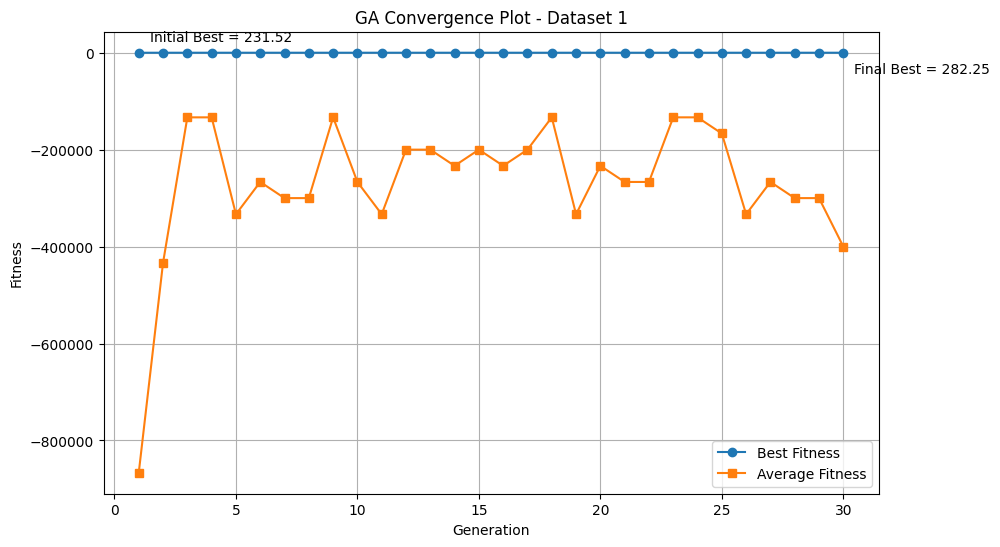

In [51]:
# =========================
# GA SEARCH + DISPLAY + CONVERGENCE PLOT
# =========================
import time
import random
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def apply_action_sequence(df, action_names, actions):
    current_df = df.copy()
    applied = []

    for action_name in action_names:
        if action_name in applied:
            continue

        next_df = actions[action_name](current_df)

        if len(next_df) == 0 or len(next_df) == len(current_df):
            continue

        current_df = next_df
        applied.append(action_name)

    return current_df, applied


def create_random_chromosome(action_names, min_len=2, max_len=5):
    k = random.randint(min_len, min(max_len, len(action_names)))
    return random.sample(action_names, k)


def mutate_chromosome(chromosome, action_names, min_len=2, max_len=5, mutation_rate=0.2):
    chromosome = chromosome.copy()

    if random.random() < mutation_rate:
        mutation_type = random.choice(["replace", "add", "remove", "shuffle"])

        if mutation_type == "replace" and len(chromosome) > 0:
            idx = random.randrange(len(chromosome))
            available = [a for a in action_names if a not in chromosome or a == chromosome[idx]]
            if available:
                chromosome[idx] = random.choice(available)

        elif mutation_type == "add" and len(chromosome) < max_len:
            available = [a for a in action_names if a not in chromosome]
            if available:
                chromosome.append(random.choice(available))

        elif mutation_type == "remove" and len(chromosome) > min_len:
            idx = random.randrange(len(chromosome))
            chromosome.pop(idx)

        elif mutation_type == "shuffle" and len(chromosome) > 1:
            random.shuffle(chromosome)

    deduped = []
    seen = set()
    for a in chromosome:
        if a not in seen:
            deduped.append(a)
            seen.add(a)

    if len(deduped) < min_len:
        available = [a for a in action_names if a not in deduped]
        while len(deduped) < min_len and available:
            chosen = random.choice(available)
            deduped.append(chosen)
            available.remove(chosen)

    return deduped[:max_len]


def crossover(parent1, parent2, min_len=2, max_len=5):
    merged = parent1[:]
    for gene in parent2:
        if gene not in merged:
            merged.append(gene)

    random.shuffle(merged)
    child_len = random.randint(min_len, min(max_len, len(merged)))
    return merged[:child_len]


def fitness_function(df_result, applied_actions, ranking_context):
    """
    Internal GA fitness.
    Keep it aligned with final ranking logic, but slightly stronger on search guidance.
    No fixed salary cap.
    """
    n = len(df_result)

    if n == 0:
        return -1e9

    if "filter_ai_related" not in applied_actions:
        return -1e6

    avg_salary = df_result["salary_final"].mean()
    if pd.isna(avg_salary):
        salary_score = 0.0
    else:
        p25 = ranking_context["salary_p25"]
        p90 = ranking_context["salary_p90"]
        salary_score = (avg_salary - p25) / (p90 - p25)
        salary_score = float(np.clip(salary_score, 0.0, 1.0))

    salary_available_ratio = df_result["salary_final"].notna().mean()
    experience_available_ratio = (df_result["formatted_experience_level"] != "Unknown").mean()
    location_available_ratio = (df_result["location"].str.len() > 0).mean()
    fulltime_ratio = df_result["formatted_work_type"].str.contains(
        r"\bfull[-\s]?time\b",
        case=False,
        na=False,
        regex=True
    ).mean()

    focus_score = 1.0 / (1.0 + np.log1p(n))
    focus_score = float(np.clip(focus_score * 3.0, 0.0, 1.0))

    action_diversity_score = min(len(applied_actions) / 6.0, 1.0)

    fitness = (
        100.0 * salary_score +
        70.0 * salary_available_ratio +
        45.0 * experience_available_ratio +
        35.0 * location_available_ratio +
        35.0 * fulltime_ratio +
        40.0 * focus_score +
        20.0 * action_diversity_score
    )

    return float(fitness)


def evaluate_chromosome(chromosome, initial_df, actions, ranking_context):
    result_df, applied_actions = apply_action_sequence(initial_df, chromosome, actions)

    if len(applied_actions) == 0:
        return {
            "chromosome": chromosome,
            "applied_actions": [],
            "depth": 0,
            "jobs_remaining": len(result_df),
            "avg_salary": np.nan,
            "ranking_quality": 0.0,
            "fitness": 0.0,
            "result_df": result_df
        }

    depth = len(applied_actions)

    avg_salary = (
        result_df["salary_final"].mean()
        if result_df["salary_final"].notna().any()
        else np.nan
    )

    ranking_quality = compute_ranking_quality(
        result_df,
        applied_actions,
        ranking_context
    )

    fitness = fitness_function(
        result_df,
        applied_actions,
        ranking_context
    )

    goal_info = {
        "chromosome": chromosome,
        "applied_actions": applied_actions,
        "depth": depth,
        "jobs_remaining": len(result_df),
        "avg_salary": avg_salary,
        "ranking_quality": ranking_quality,
        "fitness": round(fitness, 4),
        "result_df": result_df
    }

    return goal_info


def genetic_algorithm_search(
    initial_df,
    actions,
    ranking_context,
    population_size=30,
    generations=30,
    elite_size=5,
    mutation_rate=0.2,
    min_actions=2,
    max_actions=5,
    random_seed=42
):
    random.seed(random_seed)
    np.random.seed(random_seed)

    start_time = time.time()

    action_names = list(actions.keys())
    population = [
        create_random_chromosome(action_names, min_len=min_actions, max_len=max_actions)
        for _ in range(population_size)
    ]

    node_expansions = 0
    goal_states = []

    best_fitness_history = []
    avg_fitness_history = []
    best_ranking_history = []
    best_jobs_history = []
    best_actions_history = []

    for gen in range(generations):
        evaluated = []

        for chromosome in population:
            result = evaluate_chromosome(
                chromosome,
                initial_df,
                actions,
                ranking_context
            )
            evaluated.append(result)
            node_expansions += 1

            if is_goal_state(result["result_df"], result["applied_actions"]):
                goal_states.append({
                    "applied_actions": result["applied_actions"],
                    "depth": result["depth"],
                    "jobs_remaining": result["jobs_remaining"],
                    "avg_salary": result["avg_salary"],
                    "ranking_quality": result["ranking_quality"],
                    "fitness": result["fitness"],
                    "result_df": result["result_df"].copy()
                })

        evaluated.sort(
            key=lambda x: (
                x["fitness"],
                x["ranking_quality"],
                x["avg_salary"] if pd.notna(x["avg_salary"]) else -1e9,
                -x["depth"],
                -x["jobs_remaining"]
            ),
            reverse=True
        )

        generation_best = evaluated[0]
        generation_best_fitness = generation_best["fitness"]
        generation_avg_fitness = np.mean([x["fitness"] for x in evaluated])

        best_fitness_history.append(generation_best_fitness)
        avg_fitness_history.append(generation_avg_fitness)
        best_ranking_history.append(generation_best["ranking_quality"])
        best_jobs_history.append(generation_best["jobs_remaining"])
        best_actions_history.append(str(generation_best["applied_actions"]))

        elites = evaluated[:elite_size]
        new_population = [e["chromosome"] for e in elites]

        while len(new_population) < population_size:
            parent1 = random.choice(elites)["chromosome"]
            parent2 = random.choice(elites)["chromosome"]

            child = crossover(parent1, parent2, min_len=min_actions, max_len=max_actions)
            child = mutate_chromosome(
                child,
                action_names,
                min_len=min_actions,
                max_len=max_actions,
                mutation_rate=mutation_rate
            )
            new_population.append(child)

        population = new_population

    runtime = time.time() - start_time
    best_goal = select_best_goal(goal_states)

    ga_history_df = pd.DataFrame({
        "generation": range(1, len(best_fitness_history) + 1),
        "best_fitness": best_fitness_history,
        "avg_fitness": avg_fitness_history,
        "best_ranking_quality": best_ranking_history,
        "best_jobs_remaining": best_jobs_history,
        "best_actions": best_actions_history
    })

    initial_best_fitness = best_fitness_history[0] if len(best_fitness_history) > 0 else None
    final_best_fitness = best_fitness_history[-1] if len(best_fitness_history) > 0 else None
    initial_avg_fitness = avg_fitness_history[0] if len(avg_fitness_history) > 0 else None
    final_avg_fitness = avg_fitness_history[-1] if len(avg_fitness_history) > 0 else None
    fitness_improvement = (
       final_best_fitness - initial_best_fitness
       if initial_best_fitness is not None and final_best_fitness is not None
       else None
    )

    best_generation = None
    if len(ga_history_df) > 0:
        best_generation = int(ga_history_df.loc[ga_history_df["best_fitness"].idxmax(), "generation"])

    metrics = {
        "runtime_seconds": runtime,
        "node_expansions": node_expansions,
        "num_goal_states_found": len(goal_states),
        "best_jobs_remaining": best_goal["jobs_remaining"] if best_goal else None,
        "best_avg_salary": round(best_goal["avg_salary"], 2) if best_goal and pd.notna(best_goal["avg_salary"]) else None,
        "best_ranking_quality": round(best_goal["ranking_quality"], 2) if best_goal else None,
        "best_depth": best_goal["depth"] if best_goal else None,
        "best_actions": best_goal["applied_actions"] if best_goal else None,
        "convergence_generation": best_generation,
        "initial_best_fitness": round(initial_best_fitness, 4) if initial_best_fitness is not None else None,
        "final_best_fitness": round(final_best_fitness, 4) if final_best_fitness is not None else None,
        "initial_avg_fitness": round(initial_avg_fitness, 4) if initial_avg_fitness is not None else None,
        "final_avg_fitness": round(final_avg_fitness, 4) if final_avg_fitness is not None else None,
        "fitness_improvement": round(fitness_improvement, 4) if fitness_improvement is not None else None
    }

    return goal_states, best_goal, metrics, ga_history_df


# ----- RUN GA WITH PEAK MEMORY TRACKING -----
tracemalloc.start()

goal_states_ga_1, best_goal_ga_1, metrics_ga_1, ga_history_1_df = genetic_algorithm_search(
    jobs_1,
    actions_1,
    ranking_context_1,
    population_size=30,
    generations=30,
    elite_size=5,
    mutation_rate=0.2,
    min_actions=2,
    max_actions=5,
    random_seed=42
)

current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

metrics_ga_1["memory_mb"] = round(peak_mem / (1024**2), 4)

summary_ga_1_df = pd.DataFrame([{
    "algorithm": "GA",
    "dataset_name": "Dataset 1",
    "dataset_size": len(jobs_1),
    "ai_jobs_found": int(jobs_1["ai_title_flag"].sum()),
    "missing_salary_final": int(jobs_1["salary_final"].isna().sum()),
    "runtime_seconds": round(metrics_ga_1["runtime_seconds"], 4),
    "memory_mb": metrics_ga_1["memory_mb"],
    "node_expansions": metrics_ga_1["node_expansions"],
    "num_goal_states_found": metrics_ga_1["num_goal_states_found"],
    "best_jobs_remaining": metrics_ga_1["best_jobs_remaining"],
    "best_avg_salary": metrics_ga_1["best_avg_salary"],
    "best_ranking_quality": metrics_ga_1["best_ranking_quality"],
    "best_depth": metrics_ga_1["best_depth"],
    "best_actions": str(metrics_ga_1["best_actions"]),
    "convergence_generation": metrics_ga_1["convergence_generation"],
    "initial_best_fitness": metrics_ga_1["initial_best_fitness"],
    "final_best_fitness": metrics_ga_1["final_best_fitness"],
    "initial_avg_fitness": metrics_ga_1["initial_avg_fitness"],
    "final_avg_fitness": metrics_ga_1["final_avg_fitness"],
    "fitness_improvement": metrics_ga_1["fitness_improvement"]
}])

goal_states_ga_1_df = goal_states_to_df(goal_states_ga_1)

print("===== GA RESULT =====")

print("\nSummary:")
display(summary_ga_1_df)

print("\nTop 3 Goal States:")
display(goal_states_ga_1_df.head(3))

print("\nGA Convergence History:")
display(ga_history_1_df.head(3))

if best_goal_ga_1 is not None:
    print("\nBest GA Actions:", best_goal_ga_1["applied_actions"])
    print("Best GA Ranking Quality:", best_goal_ga_1["ranking_quality"])
    print("Best GA Fitness:", best_goal_ga_1["fitness"])
    print("Best GA Avg Salary:", round(best_goal_ga_1["avg_salary"], 2) if pd.notna(best_goal_ga_1["avg_salary"]) else None)

    print("\nBest GA Result Sample:")
    display(best_goal_ga_1["result_df"].head(3))
else:
    print("\nNo GA goal state found.")


# =========================
# GA CONVERGENCE PLOT
# =========================
plt.figure(figsize=(10, 6))
plt.plot(ga_history_1_df["generation"], ga_history_1_df["best_fitness"], marker="o", label="Best Fitness")
plt.plot(ga_history_1_df["generation"], ga_history_1_df["avg_fitness"], marker="s", label="Average Fitness")

if len(ga_history_1_df) > 0:
    x0 = ga_history_1_df["generation"].iloc[0]
    y0 = ga_history_1_df["best_fitness"].iloc[0]
    x1 = ga_history_1_df["generation"].iloc[-1]
    y1 = ga_history_1_df["best_fitness"].iloc[-1]

    plt.annotate(f"Initial Best = {y0:.2f}", (x0, y0), textcoords="offset points", xytext=(8, 8))
    plt.annotate(f"Final Best = {y1:.2f}", (x1, y1), textcoords="offset points", xytext=(8, -15))

plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("GA Convergence Plot - Dataset 1")
plt.legend()
plt.grid(True)
plt.show()

###**g. Compare 3 Search**

In [52]:
# =========================
# FINAL COMPARISON
# =========================
comparison_search_1_df = pd.concat([
    summary_bfs_1_df,
    summary_astar_1_df,
    summary_ga_1_df
], ignore_index=True)

print("===== FINAL COMPARISON: BFS vs A* vs GA =====")
display(comparison_search_1_df)

===== FINAL COMPARISON: BFS vs A* vs GA =====


,algorithm,dataset_name,dataset_size,ai_jobs_found,missing_salary_final,runtime_seconds,memory_mb,node_expansions,num_goal_states_found,best_jobs_remaining,best_avg_salary,best_ranking_quality,best_depth,best_actions,convergence_generation,initial_best_fitness,final_best_fitness,initial_avg_fitness,final_avg_fitness,fitness_improvement
0,BFS,Dataset 1,19001,3786,18075,44.5946,12.0984,2094,415,6,400000.00,89.03,6,"['filter_location_available', 'filter_ai_relat...",NaN,NaN,NaN,NaN,NaN,NaN
1,A*,Dataset 1,19001,3786,18075,47.6145,11.2909,2094,415,6,400000.00,89.03,6,"['filter_location_available', 'filter_ai_relat...",NaN,NaN,NaN,NaN,NaN,NaN
2,GA,Dataset 1,19001,3786,18075,41.9308,30.6459,900,658,9,271111.11,81.08,4,"['filter_work_type_full_time', 'filter_experie...",4.0,231.5169,282.2467,-866649.1717,-399841.8337,50.7298


##**2. Sample Dataset 2**

In [53]:
df_2 = pd.read_csv("/content/drive/MyDrive/Sample Dataset-3 Job posted LinkedIn (2023 - 2024).csv")
print(df_2.columns.tolist())

['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']


###**a. Load & Prepare Sample Dataset 2**

In [54]:
import re
import numpy as np
import pandas as pd

# =========================
# 1. LOAD + PREPARE DATASET 2
# =========================
def load_and_prepare_dataset(file_path, nrows=None):
    cols = [
        "job_id",
        "title",
        "location",
        "formatted_work_type",
        "formatted_experience_level",
        "min_salary",
        "max_salary",
        "normalized_salary"
    ]

    df = pd.read_csv(file_path, usecols=cols, nrows=nrows)
    jobs = df.copy()

    # -------------------------
    # Clean numeric salary columns
    # Remove only clearly invalid / unrealistic values
    # -------------------------
    for col in ["min_salary", "max_salary", "normalized_salary"]:
        jobs[col] = pd.to_numeric(jobs[col], errors="coerce")
        jobs.loc[(jobs[col] <= 0) | (jobs[col] > 5_000_000), col] = np.nan

    # If min_salary > max_salary, swap
    both_salary = jobs["min_salary"].notna() & jobs["max_salary"].notna()
    swap_mask = both_salary & (jobs["min_salary"] > jobs["max_salary"])
    jobs.loc[swap_mask, ["min_salary", "max_salary"]] = jobs.loc[
        swap_mask, ["max_salary", "min_salary"]
    ].values

    # -------------------------
    # Clean text columns
    # -------------------------
    for col in ["title", "location", "formatted_work_type"]:
        jobs[col] = (
            jobs[col]
            .fillna("")
            .astype(str)
            .str.strip()
        )

    jobs["formatted_experience_level"] = (
        jobs["formatted_experience_level"]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .replace("", "Unknown")
    )

    # -------------------------
    # Helper normalized text columns
    # -------------------------
    jobs["title_clean"] = jobs["title"].str.lower()
    jobs["location_clean"] = jobs["location"].str.lower()
    jobs["work_type_clean"] = jobs["formatted_work_type"].str.lower()
    jobs["experience_clean"] = jobs["formatted_experience_level"].str.lower()

    # -------------------------
    # Salary final construction
    # Priority:
    # 1. normalized_salary
    # 2. midpoint(min,max)
    # 3. min only
    # 4. max only
    # -------------------------
    jobs["salary_final"] = np.where(
        jobs["normalized_salary"].notna(),
        jobs["normalized_salary"],
        np.where(
            jobs["min_salary"].notna() & jobs["max_salary"].notna(),
            (jobs["min_salary"] + jobs["max_salary"]) / 2,
            np.where(
                jobs["min_salary"].notna(),
                jobs["min_salary"],
                np.where(
                    jobs["max_salary"].notna(),
                    jobs["max_salary"],
                    np.nan
                )
            )
        )
    )

    # Final sanity check for derived salary
    jobs.loc[
        (jobs["salary_final"] <= 0) | (jobs["salary_final"] > 5_000_000),
        "salary_final"
    ] = np.nan

    jobs["salary_available_flag"] = jobs["salary_final"].notna()

    # -------------------------
    # Strict AI-related title flag
    # -------------------------
    jobs["ai_title_flag"] = jobs["title"].str.contains(
        r"\bAI\b|Artificial Intelligen\w+",
        case=False,
        na=False,
        regex=True
    )
    jobs = jobs.drop_duplicates(subset=["job_id"]).reset_index(drop=True)

    return jobs

In [55]:
# =========================
# 2. PREPARE DATA ONCE
# =========================
file_path = "/content/drive/MyDrive/Sample Dataset-3 Job posted LinkedIn (2023 - 2024).csv"
sizes = [10000, 30000, 50000, 100000, 123849]

prepared_jobs_dict = {}

for size in sizes:
    jobs = load_and_prepare_dataset(file_path, nrows=size)
    prepared_jobs_dict[size] = jobs

    print(f"\nDataset size: {size}")
    print("Shape:", jobs.shape)
    print("AI jobs found:", int(jobs["ai_title_flag"].sum()))
    print("Missing salary_final:", int(jobs["salary_final"].isna().sum()))
    print("Missing work_type:", int((jobs["formatted_work_type"] == "").sum()))
    print("Missing experience:", int((jobs["formatted_experience_level"] == "Unknown").sum()))


Dataset size: 10000
Shape: (10000, 15)
AI jobs found: 20
Missing salary_final: 7081
Missing work_type: 0
Missing experience: 3309

Dataset size: 30000
Shape: (30000, 15)
AI jobs found: 80
Missing salary_final: 21633
Missing work_type: 0
Missing experience: 9093

Dataset size: 50000
Shape: (50000, 15)
AI jobs found: 127
Missing salary_final: 35431
Missing work_type: 0
Missing experience: 14151

Dataset size: 100000
Shape: (100000, 15)
AI jobs found: 261
Missing salary_final: 70532
Missing work_type: 0
Missing experience: 25139

Dataset size: 123849
Shape: (123849, 15)
AI jobs found: 315
Missing salary_final: 87791
Missing work_type: 0
Missing experience: 29409


###**b. Shared Action Library**

In [56]:
# =========================
# 3. SHARED ACTION LIBRARY
# =========================
def build_action_library(df_reference=None):
    """
    Build action space for search algorithms.

    Groups:
    A. Relevance filters
    B. Data completeness filters
    C. Work type / work mode filters
    D. Experience filters
    E. Salary preference filters
    """
    actions = {}

    # -------------------------
    # A. Core relevance filter
    # -------------------------
    actions["filter_ai_related"] = lambda x: x[x["ai_title_flag"] == True]

    # -------------------------
    # B. Data quality / completeness filters
    # -------------------------
    actions["filter_salary_available"] = lambda x: x[x["salary_final"].notna()]
    actions["filter_experience_available"] = lambda x: x[x["formatted_experience_level"] != "Unknown"]
    actions["filter_location_available"] = lambda x: x[x["location"].str.len() > 0]
    actions["filter_work_type_available"] = lambda x: x[x["formatted_work_type"].str.len() > 0]

    # -------------------------
    # C. Work type / work mode filters
    # -------------------------
    work_type_values = {
        "full_time": r"\bfull[-\s]?time\b",
        "part_time": r"\bpart[-\s]?time\b",
        "contract": r"\bcontract\b",
        "internship": r"\bintern(?:ship)?\b",
        "temporary": r"\btemporary\b|\btemp\b",
        "remote": r"\bremote\b",
        "hybrid": r"\bhybrid\b",
        "on_site": r"\bon[-\s]?site\b|\bonsite\b"
    }

    for key, pattern in work_type_values.items():
        actions[f"filter_work_type_{key}"] = (
            lambda x, p=pattern: x[
                x["formatted_work_type"].str.contains(p, case=False, na=False, regex=True)
            ]
        )

    # -------------------------
    # D. Experience filters
    # -------------------------
    exp_values = {
        "entry": r"\bentry\b|\bjunior\b|\bgraduate\b",
        "associate": r"\bassociate\b",
        "mid": r"\bmid\b|\bmid[-\s]?level\b",
        "senior": r"\bsenior\b|\blead\b|\bprincipal\b",
        "mid_senior": r"\bmid[-\s]?senior\b|\bsenior\b|\blead\b",
        "director": r"\bdirector\b",
        "executive": r"\bexecutive\b|\bvp\b|\bvice president\b|\bchief\b",
        "internship": r"\bintern(?:ship)?\b"
    }

    for key, pattern in exp_values.items():
        actions[f"filter_experience_{key}"] = (
            lambda x, p=pattern: x[
                x["formatted_experience_level"].str.contains(p, case=False, na=False, regex=True)
            ]
        )

    # -------------------------
    # E. Salary preference filters
    # Dynamic quantiles, no hard salary cap
    # -------------------------
    if df_reference is not None and "salary_final" in df_reference.columns:
        valid_salary = df_reference["salary_final"].dropna()

        if len(valid_salary) > 0:
            q25 = valid_salary.quantile(0.25)
            q50 = valid_salary.quantile(0.50)
            q75 = valid_salary.quantile(0.75)
            q90 = valid_salary.quantile(0.90)

            actions["filter_salary_q25_plus"] = (
                lambda x, cutoff=q25: x[
                    x["salary_final"].notna() & (x["salary_final"] >= cutoff)
                ]
            )
            actions["filter_salary_above_median"] = (
                lambda x, cutoff=q50: x[
                    x["salary_final"].notna() & (x["salary_final"] >= cutoff)
                ]
            )
            actions["filter_salary_top_quartile"] = (
                lambda x, cutoff=q75: x[
                    x["salary_final"].notna() & (x["salary_final"] >= cutoff)
                ]
            )
            actions["filter_salary_top_decile"] = (
                lambda x, cutoff=q90: x[
                    x["salary_final"].notna() & (x["salary_final"] >= cutoff)
                ]
            )

    return actions

In [57]:
# =========================
# 4. BUILD ACTION LIBRARY FOR EACH PREPARED SIZE
# =========================
prepared_actions_dict = {}

for size, jobs in prepared_jobs_dict.items():
    prepared_actions_dict[size] = build_action_library(jobs)

actions_10000 = prepared_actions_dict[10000]
action_names_10000 = list(actions_10000.keys())

print("Number of actions for size 10000:", len(action_names_10000))
display(action_names_10000)

Number of actions for size 10000: 25


['filter_ai_related',
 'filter_salary_available',
 'filter_experience_available',
 'filter_location_available',
 'filter_work_type_available',
 'filter_work_type_full_time',
 'filter_work_type_part_time',
 'filter_work_type_contract',
 'filter_work_type_internship',
 'filter_work_type_temporary',
 'filter_work_type_remote',
 'filter_work_type_hybrid',
 'filter_work_type_on_site',
 'filter_experience_entry',
 'filter_experience_associate',
 'filter_experience_mid',
 'filter_experience_senior',
 'filter_experience_mid_senior',
 'filter_experience_director',
 'filter_experience_executive',
 'filter_experience_internship',
 'filter_salary_q25_plus',
 'filter_salary_above_median',
 'filter_salary_top_quartile',
 'filter_salary_top_decile']

###**c. Goal State & Common Helpers**

In [58]:
import numpy as np
import pandas as pd

# =========================
# 5. GOAL STATE + COMMON HELPERS
# =========================
def build_ranking_context(df_reference):
    """
    Build dataset-specific context for salary-relative scoring.
    Removes the need for a fixed salary cap.
    """
    valid_salary = df_reference["salary_final"].dropna()

    if len(valid_salary) == 0:
        salary_p25 = 0.0
        salary_p50 = 0.0
        salary_p90 = 1.0
    else:
        salary_p25 = valid_salary.quantile(0.25)
        salary_p50 = valid_salary.quantile(0.50)
        salary_p90 = valid_salary.quantile(0.90)

        if salary_p90 == salary_p25:
            salary_p90 = salary_p25 + 1.0

    return {
        "dataset_size": len(df_reference),
        "salary_p25": float(salary_p25),
        "salary_p50": float(salary_p50),
        "salary_p90": float(salary_p90)
    }

def compute_ranking_quality(
    df_result,
    applied_actions,
    ranking_context,
    target_min_size=5,
    target_max_size=30
):
    """
    Ranking score with a balanced focus band.
    Avoids over-rewarding extremely tiny subsets.
    """
    n = len(df_result)

    if n == 0:
        return 0.0

    if "filter_ai_related" not in applied_actions:
        return 0.0

    # -------------------------
    # Salary score: relative to dataset distribution
    # -------------------------
    avg_salary = df_result["salary_final"].mean()
    if pd.isna(avg_salary):
        avg_salary_score = 0.0
    else:
        p25 = ranking_context["salary_p25"]
        p90 = ranking_context["salary_p90"]
        avg_salary_score = (avg_salary - p25) / (p90 - p25)
        avg_salary_score = float(np.clip(avg_salary_score, 0.0, 1.0))

    salary_available_score = df_result["salary_final"].notna().mean()
    experience_score = (df_result["formatted_experience_level"] != "Unknown").mean()
    location_score = (df_result["location"].str.len() > 0).mean()

    fulltime_score = df_result["formatted_work_type"].str.contains(
        r"\bfull[-\s]?time\b",
        case=False,
        na=False,
        regex=True
    ).mean()

    # -------------------------
    # Balanced focus score
    # Best in a target band, not at n=1
    # -------------------------
    if target_min_size <= n <= target_max_size:
        focus_score = 1.0
    elif n < target_min_size:
        focus_score = max(0.0, n / target_min_size)
    else:
        # gradual penalty when too broad
        focus_score = max(0.0, 1.0 - ((n - target_max_size) / target_max_size))

    # Slight reward for richer filtering
    action_diversity_score = min(len(applied_actions) / 6.0, 1.0)

    score = (
        0.26 * avg_salary_score +
        0.18 * salary_available_score +
        0.15 * fulltime_score +
        0.15 * experience_score +
        0.10 * location_score +
        0.10 * focus_score +
        0.06 * action_diversity_score
    ) * 100

    return round(score, 4)

def is_goal_state(df, applied_actions, min_actions_required=2):
    """
    A state is a goal candidate if:
    - it is not empty
    - AI filtering has been applied
    - it is not too trivial
    """
    if len(df) == 0:
        return False

    if "filter_ai_related" not in applied_actions:
        return False

    if len(applied_actions) < min_actions_required:
        return False

    return True


def evaluate_goal_state(df_result, applied_actions, depth, ranking_context):
    """
    Compute evaluation info for a goal state.
    """
    avg_salary = (
        df_result["salary_final"].mean()
        if df_result["salary_final"].notna().any()
        else np.nan
    )

    ranking_quality = compute_ranking_quality(
        df_result,
        applied_actions,
        ranking_context
    )

    return {
        "applied_actions": applied_actions.copy(),
        "depth": depth,
        "jobs_remaining": len(df_result),
        "avg_salary": avg_salary,
        "ranking_quality": ranking_quality,
        "result_df": df_result.copy()
    }


def select_best_goal(goal_states):
    """
    Select best goal consistently across BFS / A* / GA.

    Priority:
    1. higher ranking_quality
    2. higher avg_salary
    3. smaller depth
    4. smaller jobs_remaining
    """
    if not goal_states:
        return None

    return max(
        goal_states,
        key=lambda x: (
            x["ranking_quality"],
            x["avg_salary"] if pd.notna(x["avg_salary"]) else -1e9,
            -x["depth"],
            -x["jobs_remaining"]
        )
    )


def make_state_signature(df, applied_actions):
    """
    Lightweight signature for duplicate detection.
    Appropriate here because states come from filter-only transitions.
    """
    if "job_id" in df.columns:
        return (
            tuple(sorted(applied_actions)),
            len(df),
            hash(tuple(sorted(df["job_id"].astype(str).tolist())))
        )

    return (tuple(sorted(applied_actions)), len(df))


def build_result_summary(algorithm_name, dataset_name, jobs_df, metrics, best_goal):
    """
    Build one-row summary table for an algorithm.
    Uses method memory from metrics, not dataset memory.
    """
    return pd.DataFrame([{
        "algorithm": algorithm_name,
        "dataset_name": dataset_name,
        "dataset_size": len(jobs_df),
        "ai_jobs_found": int(jobs_df["ai_title_flag"].sum()),
        "missing_salary_final": int(jobs_df["salary_final"].isna().sum()),
        "runtime_seconds": round(metrics["runtime_seconds"], 4),
        "memory_mb": metrics["memory_mb"],
        "node_expansions": metrics["node_expansions"],
        "num_goal_states_found": metrics["num_goal_states_found"],
        "best_jobs_remaining": metrics["best_jobs_remaining"],
        "best_avg_salary": metrics["best_avg_salary"],
        "best_ranking_quality": metrics["best_ranking_quality"],
        "best_depth": metrics["best_depth"],
        "best_actions": str(metrics["best_actions"])
    }])


def goal_states_to_df(goal_states):
    if not goal_states:
        return pd.DataFrame(columns=[
            "depth", "jobs_remaining", "avg_salary",
            "ranking_quality", "applied_actions"
        ])

    return pd.DataFrame([
        {
            "depth": g["depth"],
            "jobs_remaining": g["jobs_remaining"],
            "avg_salary": round(g["avg_salary"], 2) if pd.notna(g["avg_salary"]) else None,
            "ranking_quality": round(g["ranking_quality"], 4),
            "applied_actions": str(g["applied_actions"])
        }
        for g in goal_states
    ]).sort_values(
        by=["ranking_quality", "avg_salary", "depth"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

###**d. Build Ranking Context for Each Size**

In [59]:
# =========================
# 6. BUILD RANKING CONTEXT FOR EACH SIZE
# =========================
prepared_ranking_context_dict = {}

for size, jobs in prepared_jobs_dict.items():
    prepared_ranking_context_dict[size] = build_ranking_context(jobs)

print("Ranking contexts prepared for:", list(prepared_ranking_context_dict.keys()))

Ranking contexts prepared for: [10000, 30000, 50000, 100000, 123849]


###**e. Quick Validation**

In [60]:
# =========================
# 7. QUICK VALIDATION
# =========================
jobs_full = prepared_jobs_dict[123849]
actions_full = prepared_actions_dict[123849]
ranking_context_full = prepared_ranking_context_dict[123849]

print("Full dataset shape:", jobs_full.shape)
print("AI jobs found:", int(jobs_full["ai_title_flag"].sum()))
print("Missing salary_final:", int(jobs_full["salary_final"].isna().sum()))

sample_df = actions_full["filter_ai_related"](jobs_full.copy())
sample_actions = ["filter_ai_related"]

print("\nSample AI-related subset size:", len(sample_df))
print("Sample ranking quality:", compute_ranking_quality(
    sample_df,
    sample_actions,
    ranking_context_full
))

Full dataset shape: (123849, 15)
AI jobs found: 315
Missing salary_final: 87791

Sample AI-related subset size: 315
Sample ranking quality: 63.4


###**f. Uninformed Search: BFS**



In [61]:
import time
import tracemalloc
import pandas as pd
from collections import deque

# =========================
# BFS SEARCH
# =========================
def bfs_search_unbounded(initial_df, actions, ranking_context):
    start_time = time.time()

    queue = deque()
    queue.append((initial_df, [], 0))

    visited = set()
    node_expansions = 0
    goal_states = []

    while queue:
        current_df, applied_actions, depth = queue.popleft()

        signature = make_state_signature(current_df, applied_actions)
        if signature in visited:
            continue
        visited.add(signature)

        node_expansions += 1

        if is_goal_state(current_df, applied_actions):
            goal_states.append(
                evaluate_goal_state(
                    current_df,
                    applied_actions,
                    depth,
                    ranking_context
                )
            )

        for action_name, action_func in actions.items():
            if action_name in applied_actions:
                continue

            next_df = action_func(current_df)

            if len(next_df) == 0 or len(next_df) == len(current_df):
                continue

            next_actions = applied_actions + [action_name]
            queue.append((next_df, next_actions, depth + 1))

    runtime = time.time() - start_time
    best_goal = select_best_goal(goal_states)

    metrics = {
        "runtime_seconds": runtime,
        "node_expansions": node_expansions,
        "num_goal_states_found": len(goal_states),
        "best_jobs_remaining": best_goal["jobs_remaining"] if best_goal else None,
        "best_avg_salary": round(best_goal["avg_salary"], 2) if best_goal and pd.notna(best_goal["avg_salary"]) else None,
        "best_ranking_quality": round(best_goal["ranking_quality"], 2) if best_goal else None,
        "best_depth": best_goal["depth"] if best_goal else None,
        "best_actions": best_goal["applied_actions"] if best_goal else None
    }

    return goal_states, best_goal, metrics


# =========================
# RUN BFS FOR ALL DATASET SIZES
# =========================
results_summary_bfs = {}
summary_rows_bfs = {}

for size in sizes:
    print(f"\n===== Running BFS for dataset size: {size} =====")

    jobs = prepared_jobs_dict[size]
    actions = prepared_actions_dict[size]
    ranking_context = prepared_ranking_context_dict[size]

    tracemalloc.start()

    goal_states, best_goal, metrics = bfs_search_unbounded(
        jobs,
        actions,
        ranking_context
    )

    current_mem, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    metrics["memory_mb"] = round(peak_mem / (1024 ** 2), 4)

    results_summary_bfs[size] = {
        "goal_states": goal_states,
        "best_goal": best_goal,
        "metrics": metrics
    }

    row = {
        "dataset_size": size,
        "ai_jobs_found": int(jobs["ai_title_flag"].sum()),
        "missing_salary_final": int(jobs["salary_final"].isna().sum()),
        "runtime_seconds": round(metrics["runtime_seconds"], 4),
        "memory_mb": metrics["memory_mb"],
        "node_expansions": metrics["node_expansions"],
        "num_goal_states_found": metrics["num_goal_states_found"],
        "best_jobs_remaining": metrics["best_jobs_remaining"],
        "best_avg_salary": metrics["best_avg_salary"],
        "best_ranking_quality": metrics["best_ranking_quality"],
        "best_depth": metrics["best_depth"],
        "best_actions": str(metrics["best_actions"])
    }

    summary_rows_bfs[size] = row

    print("\nSummary:")
    display(pd.DataFrame([row]))

    print("\nTop 3 Goal States:")
    display(goal_states_to_df(goal_states).head(3))

    if best_goal is not None:
        print("\nBest BFS Actions:", best_goal["applied_actions"])
        print("Best BFS Ranking Quality:", best_goal["ranking_quality"])
        print("Best BFS Avg Salary:", round(best_goal["avg_salary"], 2) if pd.notna(best_goal["avg_salary"]) else None)

        print("\nBest BFS Result Sample:")
        display(best_goal["result_df"].head())
    else:
        print("\nNo BFS goal state found.")

summary_bfs_df = pd.DataFrame(list(summary_rows_bfs.values())).sort_values("dataset_size").reset_index(drop=True)

print("\n===== FINAL BFS SUMMARY =====")
display(summary_bfs_df)


===== Running BFS for dataset size: 10000 =====

Summary:


,dataset_size,ai_jobs_found,missing_salary_final,runtime_seconds,memory_mb,node_expansions,num_goal_states_found,best_jobs_remaining,best_avg_salary,best_ranking_quality,best_depth,best_actions
0,10000,20,7081,120.0949,28.1386,2810,715,3,179100.0,96.0,6,"['filter_salary_available', 'filter_experience..."



Top 3 Goal States:


,depth,jobs_remaining,avg_salary,ranking_quality,applied_actions
0,6,3,179100.0,96.0,"['filter_salary_available', 'filter_experience..."
1,5,3,179100.0,95.0,"['filter_salary_available', 'filter_experience..."
2,5,3,179100.0,95.0,"['filter_salary_available', 'filter_experience..."



Best BFS Actions: ['filter_salary_available', 'filter_experience_available', 'filter_work_type_full_time', 'filter_salary_q25_plus', 'filter_salary_above_median', 'filter_ai_related']
Best BFS Ranking Quality: 96.0
Best BFS Avg Salary: 179100.0

Best BFS Result Sample:


...

,depth,jobs_remaining,avg_salary,ranking_quality,applied_actions
0,6,8,220117.5,100.0,"['filter_ai_related', 'filter_salary_available..."
1,6,8,220117.5,100.0,"['filter_ai_related', 'filter_salary_available..."
2,6,8,220117.5,100.0,"['filter_ai_related', 'filter_salary_available..."



Best BFS Actions: ['filter_ai_related', 'filter_salary_available', 'filter_experience_available', 'filter_work_type_full_time', 'filter_salary_q25_plus', 'filter_experience_director']
Best BFS Ranking Quality: 100.0
Best BFS Avg Salary: 220117.5

Best BFS Result Sample:


,job_id,title,max_salary,location,min_salary,formatted_work_type,formatted_experience_level,normalized_salary,title_clean,location_clean,work_type_clean,experience_clean,salary_final,salary_available_flag,ai_title_flag
7915,3885856881,Advanced Technology Organization Grid AI/ML Lead,NaN,"Bothell, WA",NaN,Full-time,Director,218000.0,advanced technology organization grid ai/ml lead,"bothell, wa",full-time,director,218000.0,True,True
14795,3887881873,Advanced Technology Organization Grid AI/ML Lead,NaN,"Bothell, WA",NaN,Full-time,Director,218000.0,advanced technology organization grid ai/ml lead,"bothell, wa",full-time,director,218000.0,True,True
15712,3887917759,Senior AI Scientist,255816.0,"Seattle, WA",170544.0,Full-time,Director,213180.0,senior ai scientist,"seattle, wa",full-time,director,213180.0,True,True
20046,3889126316,"Director, Alliances Business Development (AI/G...",296980.0,"Armonk, NY",123740.0,Full-time,Director,210360.0,"director, alliances business development (ai/g...","armonk, ny",full-time,director,210360.0,True,True
34636,3895500255,"Senior Practice Principal -Data, Analytics, AI...",254400.0,"Texas, United States",137000.0,Full-time,Director,195700.0,"senior practice principal -data, analytics, ai...","texas, united states",full-time,director,195700.0,True,True



===== FINAL BFS SUMMARY =====


,dataset_size,ai_jobs_found,missing_salary_final,runtime_seconds,memory_mb,node_expansions,num_goal_states_found,best_jobs_remaining,best_avg_salary,best_ranking_quality,best_depth,best_actions
0,10000,20,7081,120.0949,28.1386,2810,715,3,179100.00,96.0,6,"['filter_salary_available', 'filter_experience..."
1,30000,80,21633,190.4041,75.4920,3629,972,13,245637.69,100.0,6,"['filter_ai_related', 'filter_salary_available..."
2,50000,127,35431,256.6268,124.7578,3969,1106,18,234766.11,100.0,6,"['filter_ai_related', 'filter_salary_available..."
3,100000,261,70532,385.4379,246.2728,4343,1240,8,220117.50,100.0,6,"['filter_ai_related', 'filter_salary_available..."
4,123849,315,87791,434.5027,301.3069,4415,1274,8,220117.50,100.0,6,"['filter_ai_related', 'filter_salary_available..."


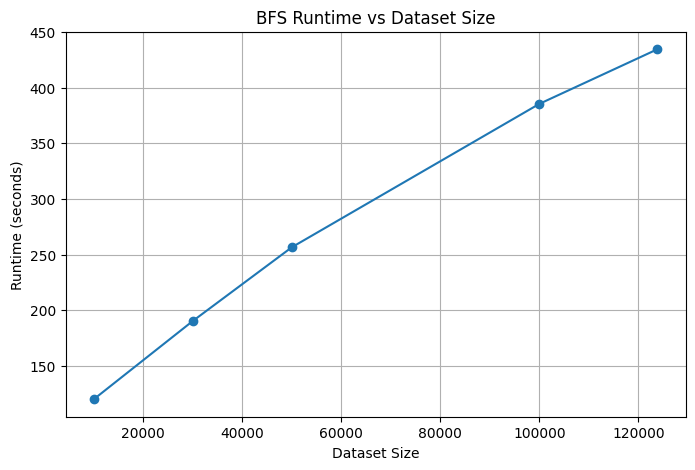

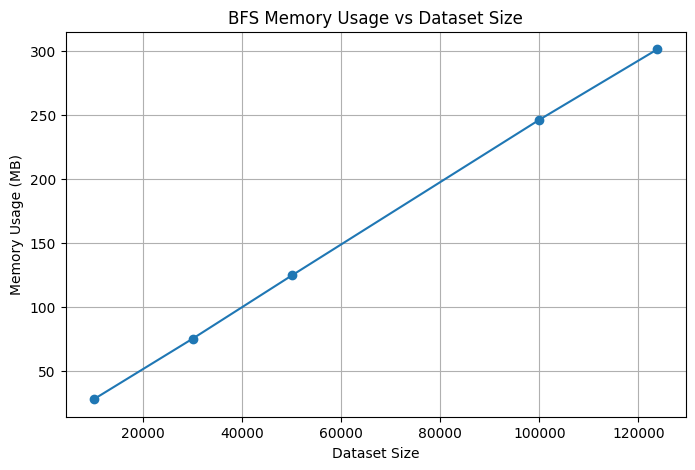

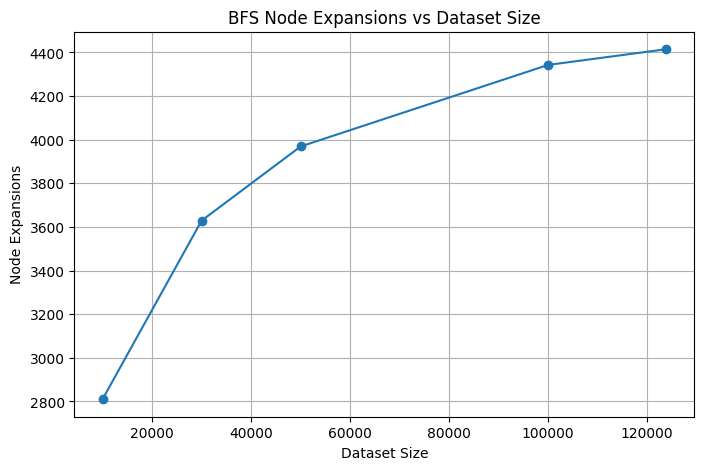

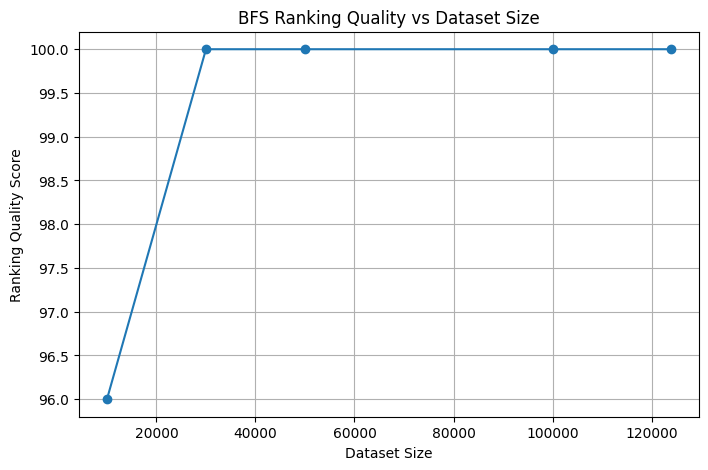

In [62]:
# =========================
# 5. BFS PLOTS
# =========================
plt.figure(figsize=(8, 5))
plt.plot(summary_bfs_df["dataset_size"], summary_bfs_df["runtime_seconds"], marker="o")
plt.xlabel("Dataset Size")
plt.ylabel("Runtime (seconds)")
plt.title("BFS Runtime vs Dataset Size")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(summary_bfs_df["dataset_size"], summary_bfs_df["memory_mb"], marker="o")
plt.xlabel("Dataset Size")
plt.ylabel("Memory Usage (MB)")
plt.title("BFS Memory Usage vs Dataset Size")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(summary_bfs_df["dataset_size"], summary_bfs_df["node_expansions"], marker="o")
plt.xlabel("Dataset Size")
plt.ylabel("Node Expansions")
plt.title("BFS Node Expansions vs Dataset Size")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(summary_bfs_df["dataset_size"], summary_bfs_df["best_ranking_quality"], marker="o")
plt.xlabel("Dataset Size")
plt.ylabel("Ranking Quality Score")
plt.title("BFS Ranking Quality vs Dataset Size")
plt.grid(True)
plt.show()

###**g. Informed Search: A***

In [63]:
import time
import heapq
import tracemalloc
import numpy as np
import pandas as pd

# =========================
# A* SEARCH + DISPLAY
# Only keep A*-specific logic here
# Assumes common helpers already exist:
# - make_state_signature
# - is_goal_state
# - evaluate_goal_state
# - select_best_goal
# - goal_states_to_df
# =========================

def heuristic_score(df, applied_actions, ranking_context, target_min_size=5, target_max_size=30):
    """
    Lower heuristic is better.

    Balanced heuristic:
    - best when subset size is within a reasonable band
    - penalises too-small and too-large subsets
    - rewards completeness, full-time concentration,
      better salary quality, and AI relevance
    """
    n = len(df)

    if n == 0:
        return 1e9

    # -------------------------
    # Balanced size penalty
    # -------------------------
    if target_min_size <= n <= target_max_size:
        size_penalty = 0.0
    elif n < target_min_size:
        size_penalty = (target_min_size - n) * 4.0
    else:
        size_penalty = np.log1p(n - target_max_size) * 10.0

    # -------------------------
    # Missing info penalties
    # -------------------------
    salary_missing_penalty = (1.0 - df["salary_final"].notna().mean()) * 25
    exp_missing_penalty = (1.0 - (df["formatted_experience_level"] != "Unknown").mean()) * 15
    location_missing_penalty = (1.0 - (df["location"].str.len() > 0).mean()) * 10

    # -------------------------
    # Full-time penalty
    # -------------------------
    fulltime_ratio = df["formatted_work_type"].str.contains(
        r"\bfull[-\s]?time\b",
        case=False,
        na=False,
        regex=True
    ).mean()
    fulltime_penalty = (1.0 - fulltime_ratio) * 12

    # -------------------------
    # Salary-quality penalty
    # -------------------------
    avg_salary = df["salary_final"].mean()
    if pd.isna(avg_salary):
        salary_quality_penalty = 20
    else:
        p25 = ranking_context["salary_p25"]
        p90 = ranking_context["salary_p90"]
        salary_score = (avg_salary - p25) / (p90 - p25)
        salary_score = float(np.clip(salary_score, 0.0, 1.0))
        salary_quality_penalty = (1.0 - salary_score) * 20

    # -------------------------
    # AI penalty
    # -------------------------
    ai_penalty = 30 if "filter_ai_related" not in applied_actions else 0

    # -------------------------
    # Slight reward for informative depth
    # -------------------------
    depth_reward = min(len(applied_actions), 5) * 2

    h = (
        size_penalty
        + salary_missing_penalty
        + exp_missing_penalty
        + location_missing_penalty
        + fulltime_penalty
        + salary_quality_penalty
        + ai_penalty
        - depth_reward
    )

    return float(max(h, 0.0))

def a_star_search(initial_df, actions, ranking_context):
    start_time = time.time()

    open_heap = []
    counter = 0

    initial_h = heuristic_score(initial_df, [], ranking_context)
    heapq.heappush(open_heap, (initial_h, 0, counter, initial_df, [], 0))

    visited = set()
    node_expansions = 0
    goal_states = []

    while open_heap:
        f_score, g_cost, _, current_df, applied_actions, depth = heapq.heappop(open_heap)

        signature = make_state_signature(current_df, applied_actions)
        if signature in visited:
            continue
        visited.add(signature)

        node_expansions += 1

        if is_goal_state(current_df, applied_actions):
            goal_states.append(
                evaluate_goal_state(
                    current_df,
                    applied_actions,
                    depth,
                    ranking_context
                )
            )

        for action_name, action_func in actions.items():
            if action_name in applied_actions:
                continue

            next_df = action_func(current_df)

            if len(next_df) == 0 or len(next_df) == len(current_df):
                continue

            next_actions = applied_actions + [action_name]
            next_depth = depth + 1
            next_g = g_cost + 1
            next_h = heuristic_score(next_df, next_actions, ranking_context)
            next_f = next_g + next_h

            counter += 1
            heapq.heappush(
                open_heap,
                (next_f, next_g, counter, next_df, next_actions, next_depth)
            )

    runtime = time.time() - start_time
    best_goal = select_best_goal(goal_states)

    metrics = {
        "runtime_seconds": runtime,
        "node_expansions": node_expansions,
        "num_goal_states_found": len(goal_states),
        "best_jobs_remaining": best_goal["jobs_remaining"] if best_goal else None,
        "best_avg_salary": round(best_goal["avg_salary"], 2) if best_goal and pd.notna(best_goal["avg_salary"]) else None,
        "best_ranking_quality": round(best_goal["ranking_quality"], 2) if best_goal else None,
        "best_depth": best_goal["depth"] if best_goal else None,
        "best_actions": best_goal["applied_actions"] if best_goal else None
    }

    return goal_states, best_goal, metrics


# =========================
# RUN A* FOR ALL DATASET SIZES
# =========================
results_summary_astar = {}
summary_rows_astar = {}

for size in sizes:
    print(f"\n===== Running A* for dataset size: {size} =====")

    jobs = prepared_jobs_dict[size]
    actions = prepared_actions_dict[size]
    ranking_context = prepared_ranking_context_dict[size]

    tracemalloc.start()

    goal_states, best_goal, metrics = a_star_search(
        jobs,
        actions,
        ranking_context
    )

    current_mem, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    metrics["memory_mb"] = round(peak_mem / (1024**2), 4)

    results_summary_astar[size] = {
        "goal_states": goal_states,
        "best_goal": best_goal,
        "metrics": metrics
    }

    row = {
        "dataset_size": size,
        "ai_jobs_found": int(jobs["ai_title_flag"].sum()),
        "missing_salary_final": int(jobs["salary_final"].isna().sum()),
        "runtime_seconds": round(metrics["runtime_seconds"], 4),
        "memory_mb": metrics["memory_mb"],
        "node_expansions": metrics["node_expansions"],
        "num_goal_states_found": metrics["num_goal_states_found"],
        "best_jobs_remaining": metrics["best_jobs_remaining"],
        "best_avg_salary": metrics["best_avg_salary"],
        "best_ranking_quality": metrics["best_ranking_quality"],
        "best_depth": metrics["best_depth"],
        "best_actions": str(metrics["best_actions"])
    }

    summary_rows_astar[size] = row

    print("\nSummary:")
    display(pd.DataFrame([row]))

    print("\nTop 3 Goal States:")
    display(goal_states_to_df(goal_states).head(3))

    if best_goal is not None:
        print("\nBest A* Actions:", best_goal["applied_actions"])
        print("Best A* Ranking Quality:", best_goal["ranking_quality"])
        print("Best A* Avg Salary:", round(best_goal["avg_salary"], 2) if pd.notna(best_goal["avg_salary"]) else None)

        print("\nBest A* Result Sample:")
        display(best_goal["result_df"].head())
    else:
        print("\nNo A* goal state found.")

summary_astar_df = pd.DataFrame(list(summary_rows_astar.values())).sort_values("dataset_size").reset_index(drop=True)

print("\n===== FINAL A* SUMMARY =====")
display(summary_astar_df)


===== Running A* for dataset size: 10000 =====

Summary:


,dataset_size,ai_jobs_found,missing_salary_final,runtime_seconds,memory_mb,node_expansions,num_goal_states_found,best_jobs_remaining,best_avg_salary,best_ranking_quality,best_depth,best_actions
0,10000,20,7081,148.4126,28.3777,2810,715,3,179100.0,96.0,6,"['filter_salary_available', 'filter_experience..."



Top 3 Goal States:


,depth,jobs_remaining,avg_salary,ranking_quality,applied_actions
0,6,3,179100.0,96.0,"['filter_salary_available', 'filter_experience..."
1,5,3,179100.0,95.0,"['filter_salary_q25_plus', 'filter_salary_abov..."
2,5,3,179100.0,95.0,"['filter_salary_available', 'filter_salary_abo..."



Best A* Actions: ['filter_salary_available', 'filter_experience_available', 'filter_salary_q25_plus', 'filter_salary_above_median', 'filter_ai_related', 'filter_work_type_full_time']
Best A* Ranking Quality: 96.0
Best A* Avg Salary: 179100.0

Best A* Result Sample:


...

,depth,jobs_remaining,avg_salary,ranking_quality,applied_actions
0,6,8,220117.5,100.0,"['filter_ai_related', 'filter_salary_top_quart..."
1,6,8,220117.5,100.0,"['filter_ai_related', 'filter_salary_above_med..."
2,6,8,220117.5,100.0,"['filter_ai_related', 'filter_salary_above_med..."



Best A* Actions: ['filter_ai_related', 'filter_salary_top_quartile', 'filter_experience_available', 'filter_salary_top_decile', 'filter_work_type_full_time', 'filter_experience_director']
Best A* Ranking Quality: 100.0
Best A* Avg Salary: 220117.5

Best A* Result Sample:


,job_id,title,max_salary,location,min_salary,formatted_work_type,formatted_experience_level,normalized_salary,title_clean,location_clean,work_type_clean,experience_clean,salary_final,salary_available_flag,ai_title_flag
7915,3885856881,Advanced Technology Organization Grid AI/ML Lead,NaN,"Bothell, WA",NaN,Full-time,Director,218000.0,advanced technology organization grid ai/ml lead,"bothell, wa",full-time,director,218000.0,True,True
14795,3887881873,Advanced Technology Organization Grid AI/ML Lead,NaN,"Bothell, WA",NaN,Full-time,Director,218000.0,advanced technology organization grid ai/ml lead,"bothell, wa",full-time,director,218000.0,True,True
15712,3887917759,Senior AI Scientist,255816.0,"Seattle, WA",170544.0,Full-time,Director,213180.0,senior ai scientist,"seattle, wa",full-time,director,213180.0,True,True
20046,3889126316,"Director, Alliances Business Development (AI/G...",296980.0,"Armonk, NY",123740.0,Full-time,Director,210360.0,"director, alliances business development (ai/g...","armonk, ny",full-time,director,210360.0,True,True
34636,3895500255,"Senior Practice Principal -Data, Analytics, AI...",254400.0,"Texas, United States",137000.0,Full-time,Director,195700.0,"senior practice principal -data, analytics, ai...","texas, united states",full-time,director,195700.0,True,True



===== FINAL A* SUMMARY =====


,dataset_size,ai_jobs_found,missing_salary_final,runtime_seconds,memory_mb,node_expansions,num_goal_states_found,best_jobs_remaining,best_avg_salary,best_ranking_quality,best_depth,best_actions
0,10000,20,7081,148.4126,28.3777,2810,715,3,179100.00,96.0,6,"['filter_salary_available', 'filter_experience..."
1,30000,80,21633,239.6399,71.6250,3629,972,13,245637.69,100.0,6,"['filter_ai_related', 'filter_salary_q25_plus'..."
2,50000,127,35431,311.2913,111.4979,3969,1106,18,234766.11,100.0,6,"['filter_ai_related', 'filter_salary_q25_plus'..."
3,100000,261,70532,464.1759,210.4992,4343,1240,8,220117.50,100.0,6,"['filter_ai_related', 'filter_salary_top_quart..."
4,123849,315,87791,522.1535,245.1661,4415,1274,8,220117.50,100.0,6,"['filter_ai_related', 'filter_salary_top_quart..."


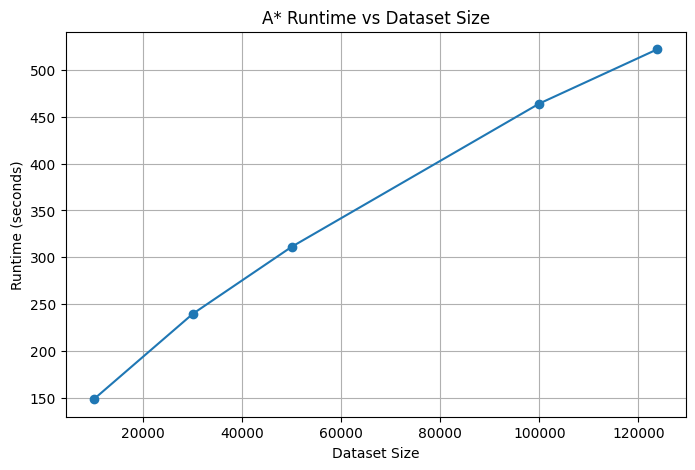

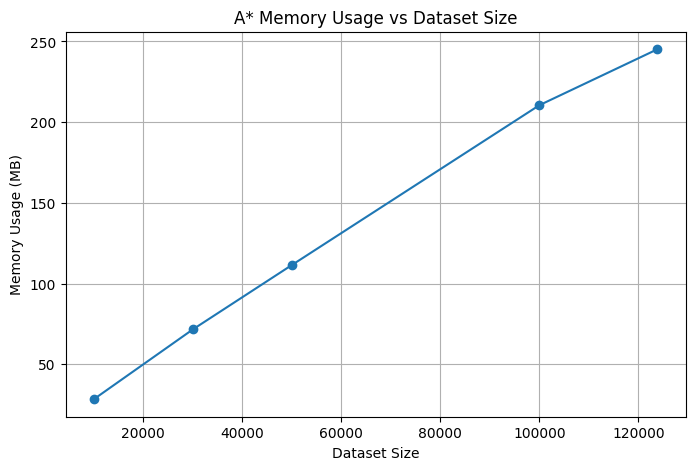

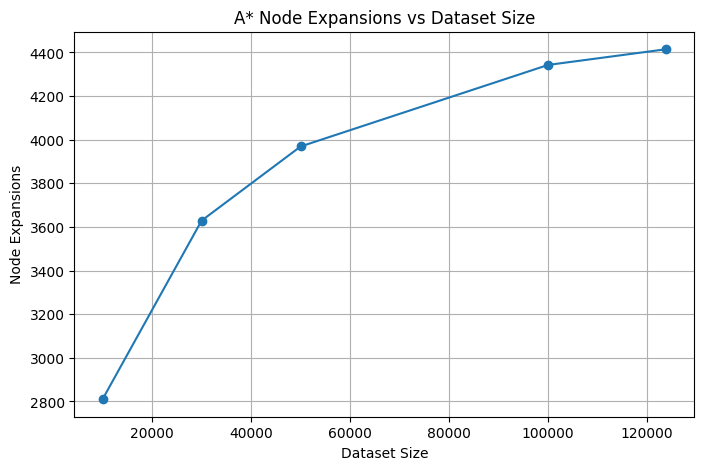

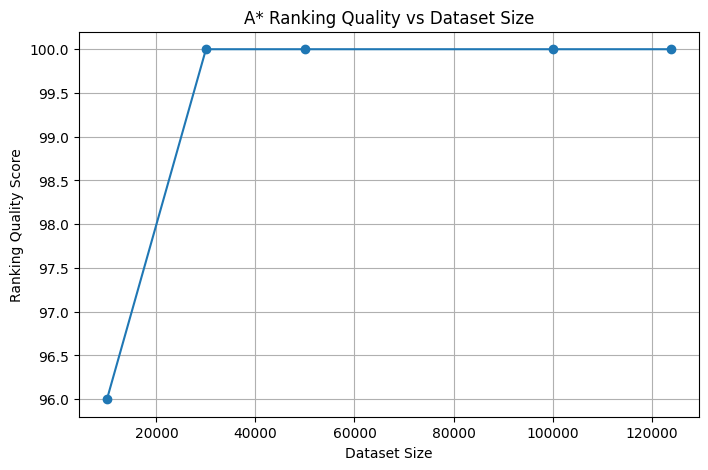

In [64]:
# =========================
# 5. A* PLOTS
# =========================
plt.figure(figsize=(8, 5))
plt.plot(summary_astar_df["dataset_size"], summary_astar_df["runtime_seconds"], marker="o")
plt.xlabel("Dataset Size")
plt.ylabel("Runtime (seconds)")
plt.title("A* Runtime vs Dataset Size")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(summary_astar_df["dataset_size"], summary_astar_df["memory_mb"], marker="o")
plt.xlabel("Dataset Size")
plt.ylabel("Memory Usage (MB)")
plt.title("A* Memory Usage vs Dataset Size")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(summary_astar_df["dataset_size"], summary_astar_df["node_expansions"], marker="o")
plt.xlabel("Dataset Size")
plt.ylabel("Node Expansions")
plt.title("A* Node Expansions vs Dataset Size")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(summary_astar_df["dataset_size"], summary_astar_df["best_ranking_quality"], marker="o")
plt.xlabel("Dataset Size")
plt.ylabel("Ranking Quality Score")
plt.title("A* Ranking Quality vs Dataset Size")
plt.grid(True)
plt.show()

###**h. Optimization Method: Genetic Algorithm (GA)**


===== Running GA for dataset size: 10000 =====

Summary:


,dataset_size,ai_jobs_found,missing_salary_final,runtime_seconds,memory_mb,node_expansions,num_goal_states_found,best_jobs_remaining,best_avg_salary,best_ranking_quality,best_depth,best_fitness,convergence_generation,initial_best_fitness,final_best_fitness,fitness_improvement,best_actions
0,10000,20,7081,46.7562,11.0134,1500,1500,3,179100.0,94.0,4,322.3333,3,317.1784,322.3333,5.1549,"['filter_ai_related', 'filter_salary_available..."



Top 3 Goal States:


,depth,jobs_remaining,avg_salary,ranking_quality,applied_actions
0,4,3,179100.0,94.0,"['filter_ai_related', 'filter_salary_available..."
1,4,3,179100.0,94.0,"['filter_ai_related', 'filter_salary_available..."
2,4,3,179100.0,94.0,"['filter_ai_related', 'filter_salary_available..."



GA Convergence History:


...

,generation,best_fitness,avg_fitness,best_ranking_quality,best_jobs_remaining,best_actions
0,1,345.0,287.919888,100.0,21,"['filter_ai_related', 'filter_experience_avail..."
1,2,345.0,319.063436,100.0,21,"['filter_ai_related', 'filter_experience_avail..."
2,3,345.0,319.155924,100.0,21,"['filter_ai_related', 'filter_experience_avail..."



Best GA Actions: ['filter_ai_related', 'filter_salary_available', 'filter_experience_available', 'filter_work_type_full_time', 'filter_experience_senior', 'filter_salary_top_decile']
Best GA Ranking Quality: 100.0
Best GA Fitness: 345.0
Best GA Avg Salary: 209031.9

Best GA Result Sample:


,job_id,title,max_salary,location,min_salary,formatted_work_type,formatted_experience_level,normalized_salary,title_clean,location_clean,work_type_clean,experience_clean,salary_final,salary_available_flag,ai_title_flag
5349,3884992282,Sr. Manager Solutions Architecture - Generativ...,312800.0,"Seattle, WA",160800.0,Full-time,Mid-Senior level,236800.0,sr. manager solutions architecture - generativ...,"seattle, wa",full-time,mid-senior level,236800.0,True,True
12111,3887576711,Principal AI/ML Data Scientist,322100.0,"San Francisco, CA",173400.0,Full-time,Mid-Senior level,247750.0,principal ai/ml data scientist,"san francisco, ca",full-time,mid-senior level,247750.0,True,True
18539,3888939625,"Modeling, Simulation & Training AI Solution Ar...",260850.0,"Orlando, FL",144300.0,Full-time,Mid-Senior level,202575.0,"modeling, simulation & training ai solution ar...","orlando, fl",full-time,mid-senior level,202575.0,True,True



===== FINAL GA SUMMARY =====


,dataset_size,ai_jobs_found,missing_salary_final,runtime_seconds,memory_mb,node_expansions,num_goal_states_found,best_jobs_remaining,best_avg_salary,best_ranking_quality,best_depth,best_fitness,convergence_generation,initial_best_fitness,final_best_fitness,fitness_improvement,best_actions
0,10000,20,7081,46.7562,11.0134,1500,1500,3,179100.00,94.0,4,322.3333,3,317.1784,322.3333,5.1549,"['filter_ai_related', 'filter_salary_available..."
1,30000,80,21633,57.4268,13.8765,1500,1500,13,245637.69,100.0,6,345.0000,23,345.0000,345.0000,0.0000,"['filter_ai_related', 'filter_salary_available..."
2,50000,127,35431,60.0139,16.0800,1500,1500,18,234766.11,100.0,6,345.0000,11,345.0000,345.0000,0.0000,"['filter_ai_related', 'filter_salary_available..."
3,100000,261,70532,76.8157,22.6770,1500,1500,19,209982.63,100.0,6,345.0000,3,345.0000,345.0000,0.0000,"['filter_ai_related', 'filter_salary_available..."
4,123849,315,87791,79.1382,25.3297,1500,1500,21,209031.90,100.0,6,345.0000,2,345.0000,345.0000,0.0000,"['filter_ai_related', 'filter_salary_available..."


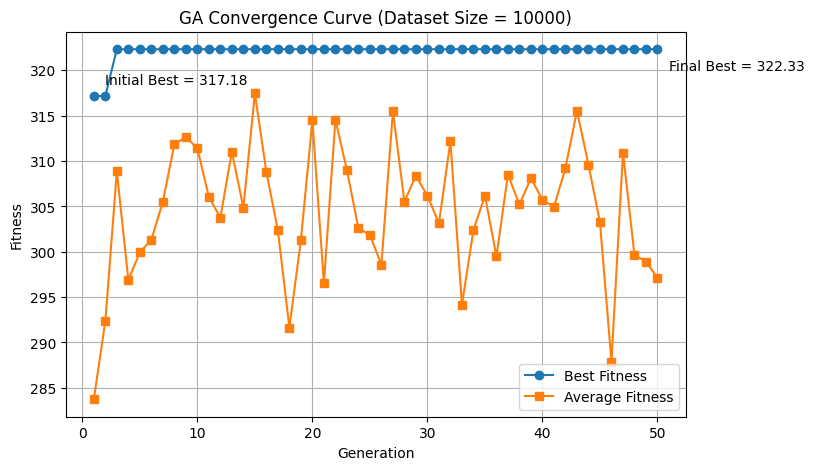

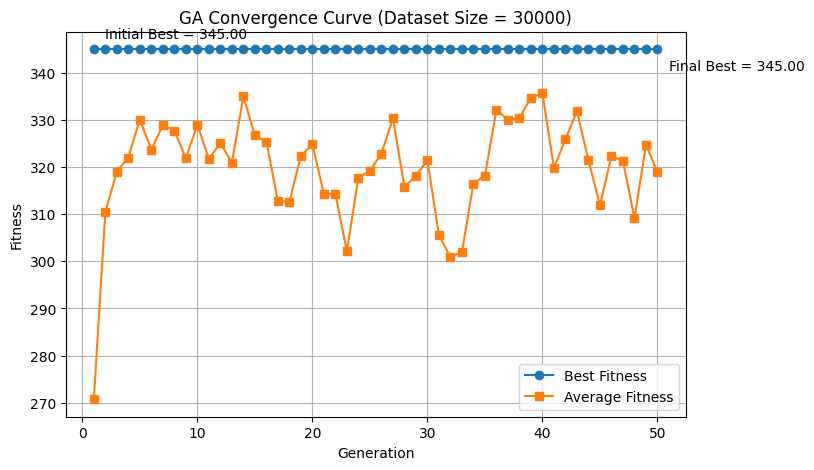

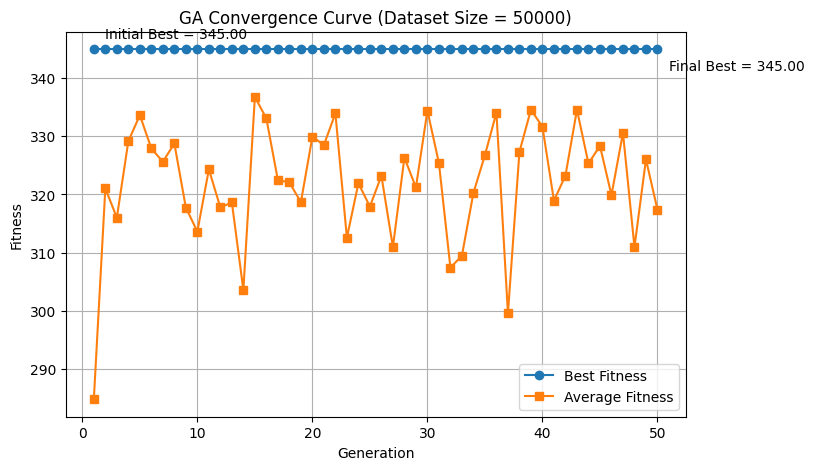

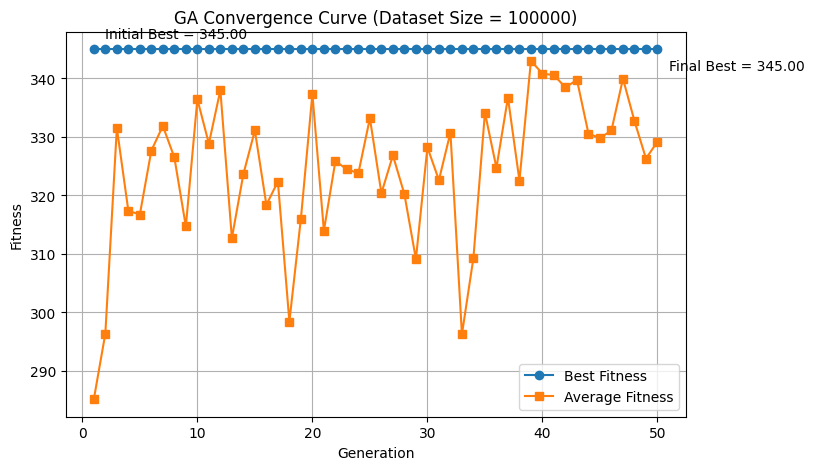

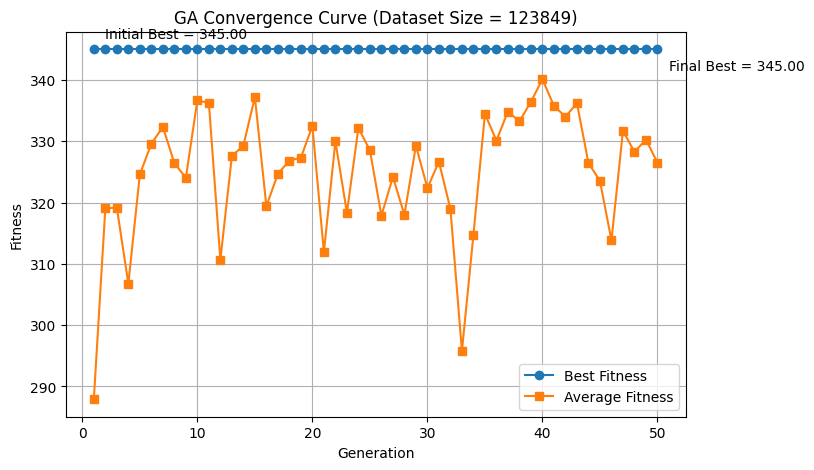

In [65]:
import time
import random
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# GA SEARCH + DISPLAY
# Assumes common helpers already exist:
# - compute_ranking_quality
# - is_goal_state
# - select_best_goal
# - goal_states_to_df
# =========================

def apply_chromosome(df, chromosome, action_names, actions):
    current_df = df.copy()
    applied_actions = []

    for gene, action_name in zip(chromosome, action_names):
        if gene == 1:
            next_df = actions[action_name](current_df)

            # skip useless transitions
            if len(next_df) == 0 or len(next_df) == len(current_df):
                continue

            current_df = next_df
            applied_actions.append(action_name)

    return current_df, applied_actions

def fitness_function(
    df_result,
    applied_actions,
    ranking_context,
    target_min_size=5,
    target_max_size=30
):
    """
    Internal GA fitness aligned with the new balanced ranking logic.
    """
    n = len(df_result)

    if n == 0:
        return -1e9

    if "filter_ai_related" not in applied_actions:
        return -1e6

    avg_salary = df_result["salary_final"].mean()
    if pd.isna(avg_salary):
        salary_score = 0.0
    else:
        p25 = ranking_context["salary_p25"]
        p90 = ranking_context["salary_p90"]
        salary_score = (avg_salary - p25) / (p90 - p25)
        salary_score = float(np.clip(salary_score, 0.0, 1.0))

    salary_available_ratio = df_result["salary_final"].notna().mean()
    experience_available_ratio = (df_result["formatted_experience_level"] != "Unknown").mean()
    location_available_ratio = (df_result["location"].str.len() > 0).mean()
    fulltime_ratio = df_result["formatted_work_type"].str.contains(
        r"\bfull[-\s]?time\b",
        case=False,
        na=False,
        regex=True
    ).mean()

    # balanced focus guidance
    if target_min_size <= n <= target_max_size:
        focus_score = 1.0
    elif n < target_min_size:
        focus_score = max(0.0, n / target_min_size)
    else:
        focus_score = max(0.0, 1.0 - ((n - target_max_size) / target_max_size))

    action_diversity_score = min(len(applied_actions) / 6.0, 1.0)

    fitness = (
        100.0 * salary_score +
        70.0 * salary_available_ratio +
        45.0 * experience_available_ratio +
        35.0 * location_available_ratio +
        35.0 * fulltime_ratio +
        40.0 * focus_score +
        20.0 * action_diversity_score
    )

    return float(fitness)

def create_random_chromosome(num_genes, ai_index=0):
    chromosome = [random.randint(0, 1) for _ in range(num_genes)]
    chromosome[ai_index] = 1
    return chromosome


def tournament_selection(population, fitnesses, tournament_size=3):
    selected_indices = random.sample(range(len(population)), tournament_size)
    best_idx = max(selected_indices, key=lambda i: fitnesses[i])
    return population[best_idx][:]


def crossover(parent1, parent2, crossover_rate=0.8, ai_index=0):
    if random.random() > crossover_rate:
        return parent1[:], parent2[:]

    point = random.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]

    child1[ai_index] = 1
    child2[ai_index] = 1

    return child1, child2


def mutate(chromosome, mutation_rate=0.1, ai_index=0):
    mutated = chromosome[:]

    for i in range(len(mutated)):
        if i == ai_index:
            continue
        if random.random() < mutation_rate:
            mutated[i] = 1 - mutated[i]

    mutated[ai_index] = 1
    return mutated


def genetic_algorithm_search(
    initial_df,
    actions,
    ranking_context,
    population_size=30,
    generations=50,
    crossover_rate=0.8,
    mutation_rate=0.1,
    elitism_size=2,
    random_seed=42
):
    random.seed(random_seed)
    np.random.seed(random_seed)

    start_time = time.time()

    action_names = list(actions.keys())
    num_genes = len(action_names)
    ai_index = action_names.index("filter_ai_related")

    population = [
        create_random_chromosome(num_genes, ai_index=ai_index)
        for _ in range(population_size)
    ]

    node_expansions = 0
    goal_states = []

    best_fitness_history = []
    avg_fitness_history = []
    best_ranking_history = []
    best_jobs_history = []
    best_actions_history = []

    for gen in range(generations):
        evaluated_population = []

        for chromosome in population:
            result_df, applied_actions = apply_chromosome(
                initial_df,
                chromosome,
                action_names,
                actions
            )

            fitness = fitness_function(
                result_df,
                applied_actions,
                ranking_context
            )

            ranking_quality = compute_ranking_quality(
                result_df,
                applied_actions,
                ranking_context
            ) if len(result_df) > 0 else 0.0

            avg_salary = (
                result_df["salary_final"].mean()
                if len(result_df) > 0 and result_df["salary_final"].notna().any()
                else np.nan
            )

            record = {
                "chromosome": chromosome[:],
                "result_df": result_df.copy(),
                "applied_actions": applied_actions[:],
                "fitness": fitness,
                "ranking_quality": ranking_quality,
                "avg_salary": avg_salary,
                "jobs_remaining": len(result_df),
                "depth": len(applied_actions),
                "generation": gen + 1
            }

            evaluated_population.append(record)
            node_expansions += 1

            if is_goal_state(result_df, applied_actions):
                goal_states.append({
                    "chromosome": chromosome[:],
                    "applied_actions": applied_actions[:],
                    "depth": len(applied_actions),
                    "jobs_remaining": len(result_df),
                    "avg_salary": avg_salary,
                    "ranking_quality": ranking_quality,
                    "fitness": fitness,
                    "generation": gen + 1,
                    "result_df": result_df.copy()
                })

        if len(evaluated_population) == 0:
            break

        evaluated_population.sort(
            key=lambda x: (
                x["fitness"],
                x["ranking_quality"],
                x["avg_salary"] if pd.notna(x["avg_salary"]) else -1e9
            ),
            reverse=True
        )

        generation_best = evaluated_population[0]
        generation_best_fitness = generation_best["fitness"]
        generation_avg_fitness = np.mean([x["fitness"] for x in evaluated_population])

        best_fitness_history.append(generation_best_fitness)
        avg_fitness_history.append(generation_avg_fitness)
        best_ranking_history.append(generation_best["ranking_quality"])
        best_jobs_history.append(generation_best["jobs_remaining"])
        best_actions_history.append(str(generation_best["applied_actions"]))

        elites = evaluated_population[:elitism_size]
        new_population = [item["chromosome"][:] for item in elites]

        while len(new_population) < population_size:
            parent1 = tournament_selection(
                [x["chromosome"] for x in evaluated_population],
                [x["fitness"] for x in evaluated_population]
            )
            parent2 = tournament_selection(
                [x["chromosome"] for x in evaluated_population],
                [x["fitness"] for x in evaluated_population]
            )

            child1, child2 = crossover(
                parent1,
                parent2,
                crossover_rate=crossover_rate,
                ai_index=ai_index
            )

            child1 = mutate(child1, mutation_rate=mutation_rate, ai_index=ai_index)
            child2 = mutate(child2, mutation_rate=mutation_rate, ai_index=ai_index)

            new_population.append(child1)
            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population[:population_size]

    runtime = time.time() - start_time

    best_goal = select_best_goal(goal_states)

    ga_history_df = pd.DataFrame({
        "generation": range(1, len(best_fitness_history) + 1),
        "best_fitness": best_fitness_history,
        "avg_fitness": avg_fitness_history,
        "best_ranking_quality": best_ranking_history,
        "best_jobs_remaining": best_jobs_history,
        "best_actions": best_actions_history
    })

    initial_best_fitness = best_fitness_history[0] if len(best_fitness_history) > 0 else None
    final_best_fitness = best_fitness_history[-1] if len(best_fitness_history) > 0 else None
    initial_avg_fitness = avg_fitness_history[0] if len(avg_fitness_history) > 0 else None
    final_avg_fitness = avg_fitness_history[-1] if len(avg_fitness_history) > 0 else None
    fitness_improvement = (
        final_best_fitness - initial_best_fitness
        if initial_best_fitness is not None and final_best_fitness is not None
        else None
    )

    metrics = {
        "runtime_seconds": runtime,
        "node_expansions": node_expansions,
        "num_goal_states_found": len(goal_states),
        "best_jobs_remaining": best_goal["jobs_remaining"] if best_goal else None,
        "best_avg_salary": round(best_goal["avg_salary"], 2) if best_goal and pd.notna(best_goal["avg_salary"]) else None,
        "best_ranking_quality": round(best_goal["ranking_quality"], 2) if best_goal else None,
        "best_depth": best_goal["depth"] if best_goal else None,
        "best_actions": best_goal["applied_actions"] if best_goal else None,
        "best_fitness": round(best_goal["fitness"], 4) if best_goal else None,
        "convergence_generation": best_goal["generation"] if best_goal else None,
        "initial_best_fitness": round(initial_best_fitness, 4) if initial_best_fitness is not None else None,
        "final_best_fitness": round(final_best_fitness, 4) if final_best_fitness is not None else None,
        "initial_avg_fitness": round(initial_avg_fitness, 4) if initial_avg_fitness is not None else None,
        "final_avg_fitness": round(final_avg_fitness, 4) if final_avg_fitness is not None else None,
        "fitness_improvement": round(fitness_improvement, 4) if fitness_improvement is not None else None
    }

    return goal_states, best_goal, metrics, ga_history_df


# =========================
# RUN GA FOR ALL DATASET SIZES
# =========================
results_summary_ga = {}
summary_rows_ga = {}
convergence_dict_ga = {}

for size in sizes:
    print(f"\n===== Running GA for dataset size: {size} =====")

    jobs = prepared_jobs_dict[size]
    actions = prepared_actions_dict[size]
    ranking_context = prepared_ranking_context_dict[size]

    tracemalloc.start()

    goal_states, best_goal, metrics, ga_history_df = genetic_algorithm_search(
        jobs,
        actions,
        ranking_context,
        population_size=30,
        generations=50,
        crossover_rate=0.8,
        mutation_rate=0.1,
        elitism_size=2,
        random_seed=42
    )

    current_mem, peak_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    metrics["memory_mb"] = round(peak_mem / (1024 ** 2), 4)

    results_summary_ga[size] = {
        "goal_states": goal_states,
        "best_goal": best_goal,
        "metrics": metrics,
        "history_df": ga_history_df
    }

    convergence_dict_ga[size] = ga_history_df

    row = {
        "dataset_size": size,
        "ai_jobs_found": int(jobs["ai_title_flag"].sum()),
        "missing_salary_final": int(jobs["salary_final"].isna().sum()),
        "runtime_seconds": round(metrics["runtime_seconds"], 4),
        "memory_mb": metrics["memory_mb"],
        "node_expansions": metrics["node_expansions"],
        "num_goal_states_found": metrics["num_goal_states_found"],
        "best_jobs_remaining": metrics["best_jobs_remaining"],
        "best_avg_salary": metrics["best_avg_salary"],
        "best_ranking_quality": metrics["best_ranking_quality"],
        "best_depth": metrics["best_depth"],
        "best_fitness": metrics["best_fitness"],
        "convergence_generation": metrics["convergence_generation"],
        "initial_best_fitness": metrics["initial_best_fitness"],
        "final_best_fitness": metrics["final_best_fitness"],
        "fitness_improvement": metrics["fitness_improvement"],
        "best_actions": str(metrics["best_actions"])
    }

    summary_rows_ga[size] = row

    print("\nSummary:")
    display(pd.DataFrame([row]))

    print("\nTop 3 Goal States:")
    display(goal_states_to_df(goal_states).head(3))

    print("\nGA Convergence History:")
    display(ga_history_df.head(3))

    if best_goal is not None:
        print("\nBest GA Actions:", best_goal["applied_actions"])
        print("Best GA Ranking Quality:", best_goal["ranking_quality"])
        print("Best GA Fitness:", round(best_goal["fitness"], 4))
        print("Best GA Avg Salary:", round(best_goal["avg_salary"], 2) if pd.notna(best_goal["avg_salary"]) else None)

        print("\nBest GA Result Sample:")
        display(best_goal["result_df"].head(3))
    else:
        print("\nNo GA goal state found.")

summary_ga_df = pd.DataFrame(list(summary_rows_ga.values())).sort_values("dataset_size").reset_index(drop=True)

print("\n===== FINAL GA SUMMARY =====")
display(summary_ga_df)


# =========================
# GA CONVERGENCE PLOT FOR EACH DATASET SIZE
# =========================
for size in sizes:
    history_df = convergence_dict_ga[size]

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["generation"], history_df["best_fitness"], marker="o", label="Best Fitness")
    plt.plot(history_df["generation"], history_df["avg_fitness"], marker="s", label="Average Fitness")

    if len(history_df) > 0:
        x0 = history_df["generation"].iloc[0]
        y0 = history_df["best_fitness"].iloc[0]
        x1 = history_df["generation"].iloc[-1]
        y1 = history_df["best_fitness"].iloc[-1]

        plt.annotate(f"Initial Best = {y0:.2f}", (x0, y0), textcoords="offset points", xytext=(8, 8))
        plt.annotate(f"Final Best = {y1:.2f}", (x1, y1), textcoords="offset points", xytext=(8, -15))

    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.title(f"GA Convergence Curve (Dataset Size = {size})")
    plt.legend()
    plt.grid(True)
    plt.show()

###**i. Compare 3 Search**


===== BFS vs A* vs GA COMPARISON TABLE =====


,dataset_size,ai_jobs_found,missing_salary_final,bfs_runtime_seconds,bfs_memory_mb,bfs_node_expansions,bfs_num_goal_states_found,bfs_best_jobs_remaining,bfs_best_avg_salary,bfs_best_ranking_quality,...,ga_best_jobs_remaining,ga_best_avg_salary,ga_best_ranking_quality,ga_best_depth,ga_best_fitness,ga_convergence_generation,ga_initial_best_fitness,ga_final_best_fitness,ga_fitness_improvement,ga_best_actions
0,10000,20,7081,120.0949,28.1386,2810,715,3,179100.00,96.0,...,3,179100.00,94.0,4,322.3333,3,317.1784,322.3333,5.1549,"['filter_ai_related', 'filter_salary_available..."
1,30000,80,21633,190.4041,75.4920,3629,972,13,245637.69,100.0,...,13,245637.69,100.0,6,345.0000,23,345.0000,345.0000,0.0000,"['filter_ai_related', 'filter_salary_available..."
2,50000,127,35431,256.6268,124.7578,3969,1106,18,234766.11,100.0,...,18,234766.11,100.0,6,345.0000,11,345.0000,345.0000,0.0000,"['filter_ai_related', 'filter_salary_available..."
3,100000,261,70532,385.4379,246.2728,4343,1240,8,220117.50,100.0,...,19,209982.63,100.0,6,345.0000,3,345.0000,345.0000,0.0000,"['filter_ai_related', 'filter_salary_available..."
4,123849,315,87791,434.5027,301.3069,4415,1274,8,220117.50,100.0,...,21,209031.90,100.0,6,345.0000,2,345.0000,345.0000,0.0000,"['filter_ai_related', 'filter_salary_available..."


===== COMPACT COMPARISON (4 METRICS) =====


,Dataset Size,BFS Runtime (s),A* Runtime (s),GA Runtime (s),BFS Memory (MB),A* Memory (MB),GA Memory (MB),BFS Node Exp.,A* Node Exp.,GA Fitness Eval.,BFS Ranking,A* Ranking,GA Ranking
0,10000,120.095,148.413,46.756,28.139,28.378,11.013,2810,2810,1500,96.0,96.0,94.0
1,30000,190.404,239.640,57.427,75.492,71.625,13.876,3629,3629,1500,100.0,100.0,100.0
2,50000,256.627,311.291,60.014,124.758,111.498,16.080,3969,3969,1500,100.0,100.0,100.0
3,100000,385.438,464.176,76.816,246.273,210.499,22.677,4343,4343,1500,100.0,100.0,100.0
4,123849,434.503,522.154,79.138,301.307,245.166,25.330,4415,4415,1500,100.0,100.0,100.0


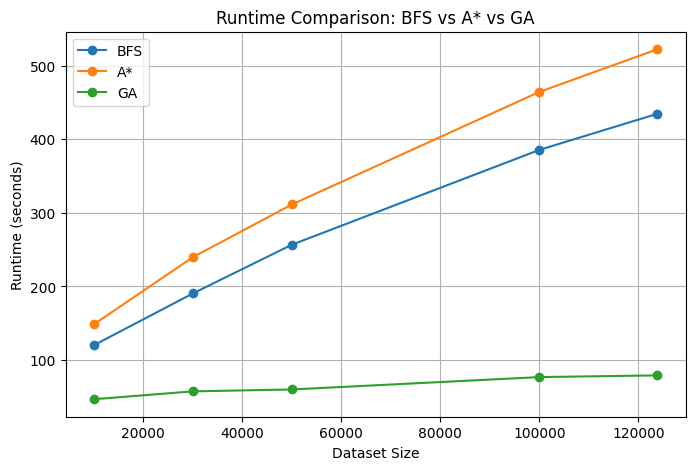

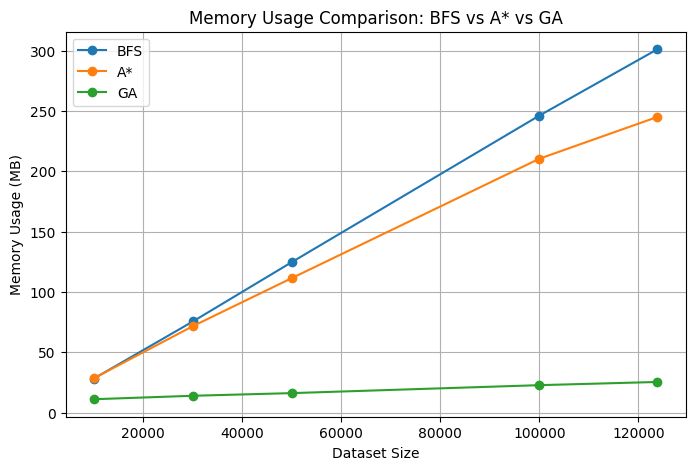

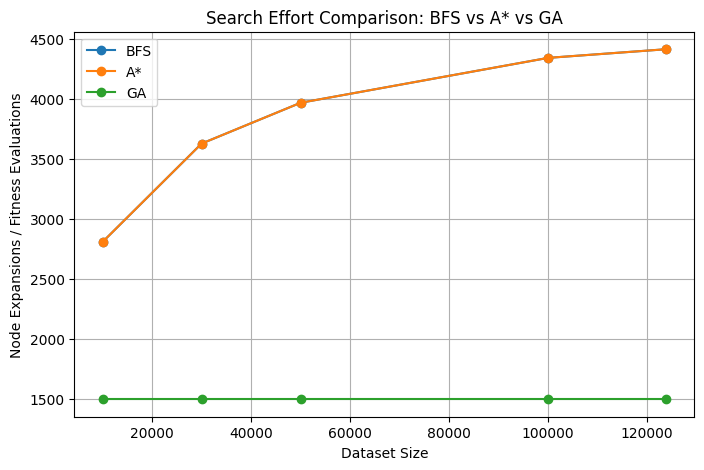

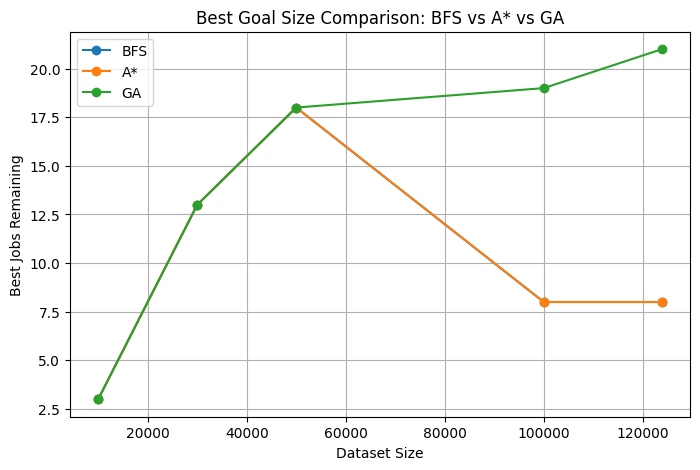

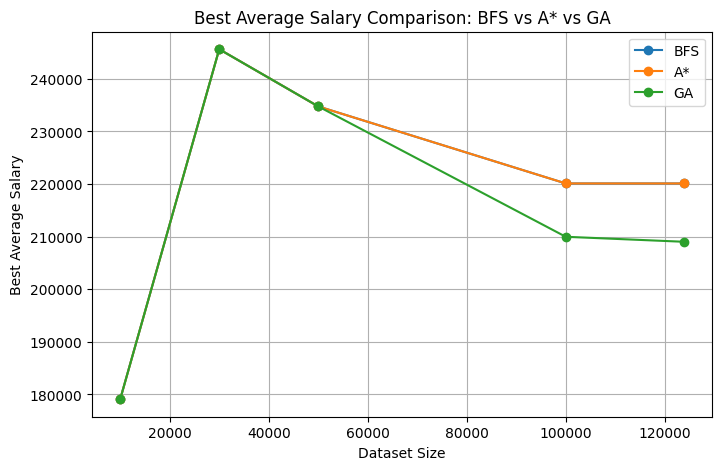

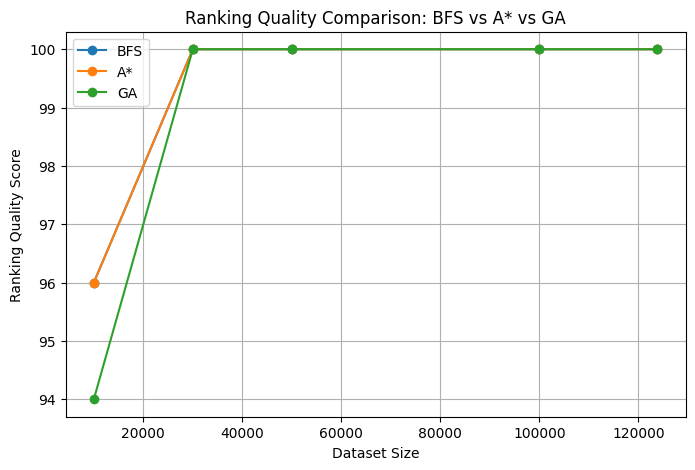


===== GA CONVERGENCE SUMMARY =====


,dataset_size,ga_initial_best_fitness,ga_final_best_fitness,ga_fitness_improvement,ga_best_fitness,ga_convergence_generation
0,10000,317.1784,322.3333,5.1549,322.3333,3
1,30000,345.0000,345.0000,0.0000,345.0000,23
2,50000,345.0000,345.0000,0.0000,345.0000,11
3,100000,345.0000,345.0000,0.0000,345.0000,3
4,123849,345.0000,345.0000,0.0000,345.0000,2


In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. CHECK REQUIRED SUMMARY TABLES
# Assumes these already exist:
# - summary_bfs_df
# - summary_astar_df
# - summary_ga_df
# =========================================================
required_tables = ["summary_bfs_df", "summary_astar_df", "summary_ga_df"]
for name in required_tables:
    if name not in globals():
        raise ValueError(f"{name} is not defined. Please run the corresponding search first.")


# =========================================================
# 2. STANDARDISE COLUMNS FOR COMPARISON
# Keep only fields that matter for algorithm comparison
# =========================================================
bfs_compare = summary_bfs_df.copy()[[
    "dataset_size",
    "ai_jobs_found",
    "missing_salary_final",
    "runtime_seconds",
    "memory_mb",
    "node_expansions",
    "num_goal_states_found",
    "best_jobs_remaining",
    "best_avg_salary",
    "best_ranking_quality",
    "best_depth",
    "best_actions"
]].rename(columns={
    "runtime_seconds": "bfs_runtime_seconds",
    "memory_mb": "bfs_memory_mb",
    "node_expansions": "bfs_node_expansions",
    "num_goal_states_found": "bfs_num_goal_states_found",
    "best_jobs_remaining": "bfs_best_jobs_remaining",
    "best_avg_salary": "bfs_best_avg_salary",
    "best_ranking_quality": "bfs_best_ranking_quality",
    "best_depth": "bfs_best_depth",
    "best_actions": "bfs_best_actions"
})

astar_compare = summary_astar_df.copy()[[
    "dataset_size",
    "runtime_seconds",
    "memory_mb",
    "node_expansions",
    "num_goal_states_found",
    "best_jobs_remaining",
    "best_avg_salary",
    "best_ranking_quality",
    "best_depth",
    "best_actions"
]].rename(columns={
    "runtime_seconds": "astar_runtime_seconds",
    "memory_mb": "astar_memory_mb",
    "node_expansions": "astar_node_expansions",
    "num_goal_states_found": "astar_num_goal_states_found",
    "best_jobs_remaining": "astar_best_jobs_remaining",
    "best_avg_salary": "astar_best_avg_salary",
    "best_ranking_quality": "astar_best_ranking_quality",
    "best_depth": "astar_best_depth",
    "best_actions": "astar_best_actions"
})

ga_compare = summary_ga_df.copy()[[
    "dataset_size",
    "runtime_seconds",
    "memory_mb",
    "node_expansions",
    "num_goal_states_found",
    "best_jobs_remaining",
    "best_avg_salary",
    "best_ranking_quality",
    "best_depth",
    "best_fitness",
    "convergence_generation",
    "initial_best_fitness",
    "final_best_fitness",
    "fitness_improvement",
    "best_actions"
]].rename(columns={
    "runtime_seconds": "ga_runtime_seconds",
    "memory_mb": "ga_memory_mb",
    "node_expansions": "ga_node_expansions",
    "num_goal_states_found": "ga_num_goal_states_found",
    "best_jobs_remaining": "ga_best_jobs_remaining",
    "best_avg_salary": "ga_best_avg_salary",
    "best_ranking_quality": "ga_best_ranking_quality",
    "best_depth": "ga_best_depth",
    "best_fitness": "ga_best_fitness",
    "convergence_generation": "ga_convergence_generation",
    "initial_best_fitness": "ga_initial_best_fitness",
    "final_best_fitness": "ga_final_best_fitness",
    "fitness_improvement": "ga_fitness_improvement",
    "best_actions": "ga_best_actions"
})


# =========================================================
# 3. MERGE INTO ONE COMPARISON TABLE
# =========================================================
comparison_df = bfs_compare.merge(astar_compare, on="dataset_size", how="inner")
comparison_df = comparison_df.merge(ga_compare, on="dataset_size", how="inner")

numeric_cols = comparison_df.select_dtypes(include=["float64", "int64"]).columns
comparison_df[numeric_cols] = comparison_df[numeric_cols].round(4)

comparison_df = comparison_df.sort_values("dataset_size").reset_index(drop=True)

print("\n===== BFS vs A* vs GA COMPARISON TABLE =====")
display(comparison_df)


# =========================
# COMPACT TABLE
# =========================
compact_metrics_df = comparison_df[[
    "dataset_size",

    # Runtime
    "bfs_runtime_seconds",
    "astar_runtime_seconds",
    "ga_runtime_seconds",

    # Memory
    "bfs_memory_mb",
    "astar_memory_mb",
    "ga_memory_mb",

    # Node expansions
    "bfs_node_expansions",
    "astar_node_expansions",
    "ga_node_expansions",

    # Ranking quality
    "bfs_best_ranking_quality",
    "astar_best_ranking_quality",
    "ga_best_ranking_quality"
]].copy()

# Rename
compact_metrics_df = compact_metrics_df.rename(columns={
    "dataset_size": "Dataset Size",

    "bfs_runtime_seconds": "BFS Runtime (s)",
    "astar_runtime_seconds": "A* Runtime (s)",
    "ga_runtime_seconds": "GA Runtime (s)",

    "bfs_memory_mb": "BFS Memory (MB)",
    "astar_memory_mb": "A* Memory (MB)",
    "ga_memory_mb": "GA Memory (MB)",

    "bfs_node_expansions": "BFS Node Exp.",
    "astar_node_expansions": "A* Node Exp.",
    "ga_node_expansions": "GA Fitness Eval.",

    "bfs_best_ranking_quality": "BFS Ranking",
    "astar_best_ranking_quality": "A* Ranking",
    "ga_best_ranking_quality": "GA Ranking"
})

# Round
numeric_cols = compact_metrics_df.select_dtypes(include=["float64", "int64"]).columns
compact_metrics_df[numeric_cols] = compact_metrics_df[numeric_cols].round(3)

print("===== COMPACT COMPARISON (4 METRICS) =====")
display(compact_metrics_df)


# =========================================================
# 5. PLOT: RUNTIME COMPARISON
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(comparison_df["dataset_size"], comparison_df["bfs_runtime_seconds"], marker="o", label="BFS")
plt.plot(comparison_df["dataset_size"], comparison_df["astar_runtime_seconds"], marker="o", label="A*")
plt.plot(comparison_df["dataset_size"], comparison_df["ga_runtime_seconds"], marker="o", label="GA")
plt.xlabel("Dataset Size")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison: BFS vs A* vs GA")
plt.grid(True)
plt.legend()
plt.show()


# =========================================================
# 6. PLOT: MEMORY USAGE COMPARISON
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(comparison_df["dataset_size"], comparison_df["bfs_memory_mb"], marker="o", label="BFS")
plt.plot(comparison_df["dataset_size"], comparison_df["astar_memory_mb"], marker="o", label="A*")
plt.plot(comparison_df["dataset_size"], comparison_df["ga_memory_mb"], marker="o", label="GA")
plt.xlabel("Dataset Size")
plt.ylabel("Memory Usage (MB)")
plt.title("Memory Usage Comparison: BFS vs A* vs GA")
plt.grid(True)
plt.legend()
plt.show()


# =========================================================
# 7. PLOT: SEARCH EFFORT COMPARISON
# BFS/A* = node expansions
# GA = fitness evaluations
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(comparison_df["dataset_size"], comparison_df["bfs_node_expansions"], marker="o", label="BFS")
plt.plot(comparison_df["dataset_size"], comparison_df["astar_node_expansions"], marker="o", label="A*")
plt.plot(comparison_df["dataset_size"], comparison_df["ga_node_expansions"], marker="o", label="GA")
plt.xlabel("Dataset Size")
plt.ylabel("Node Expansions / Fitness Evaluations")
plt.title("Search Effort Comparison: BFS vs A* vs GA")
plt.grid(True)
plt.legend()
plt.show()


# =========================================================
# 8. PLOT: BEST JOBS REMAINING
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(comparison_df["dataset_size"], comparison_df["bfs_best_jobs_remaining"], marker="o", label="BFS")
plt.plot(comparison_df["dataset_size"], comparison_df["astar_best_jobs_remaining"], marker="o", label="A*")
plt.plot(comparison_df["dataset_size"], comparison_df["ga_best_jobs_remaining"], marker="o", label="GA")
plt.xlabel("Dataset Size")
plt.ylabel("Best Jobs Remaining")
plt.title("Best Goal Size Comparison: BFS vs A* vs GA")
plt.grid(True)
plt.legend()
plt.show()


# =========================================================
# 9. PLOT: BEST AVERAGE SALARY
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(comparison_df["dataset_size"], comparison_df["bfs_best_avg_salary"], marker="o", label="BFS")
plt.plot(comparison_df["dataset_size"], comparison_df["astar_best_avg_salary"], marker="o", label="A*")
plt.plot(comparison_df["dataset_size"], comparison_df["ga_best_avg_salary"], marker="o", label="GA")
plt.xlabel("Dataset Size")
plt.ylabel("Best Average Salary")
plt.title("Best Average Salary Comparison: BFS vs A* vs GA")
plt.grid(True)
plt.legend()
plt.show()


# =========================================================
# 10. PLOT: BEST RANKING QUALITY
# This is the most important comparison plot
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(comparison_df["dataset_size"], comparison_df["bfs_best_ranking_quality"], marker="o", label="BFS")
plt.plot(comparison_df["dataset_size"], comparison_df["astar_best_ranking_quality"], marker="o", label="A*")
plt.plot(comparison_df["dataset_size"], comparison_df["ga_best_ranking_quality"], marker="o", label="GA")
plt.xlabel("Dataset Size")
plt.ylabel("Ranking Quality Score")
plt.title("Ranking Quality Comparison: BFS vs A* vs GA")
plt.grid(True)
plt.legend()
plt.show()

# =========================================================
# 11. GA CONVERGENCE SUMMARY TABLE
# Keep because it is uniquely relevant to GA
# =========================================================
ga_convergence_table = comparison_df[[
    "dataset_size",
    "ga_initial_best_fitness",
    "ga_final_best_fitness",
    "ga_fitness_improvement",
    "ga_best_fitness",
    "ga_convergence_generation"
]].copy()

print("\n===== GA CONVERGENCE SUMMARY =====")
display(ga_convergence_table)

##**3. Compare Cross Dataset**

In [67]:
# =========================
# CROSS DATASET COMPARISON (WITH GA CONVERGENCE)
# =========================

# ---------- DATASET 1 ----------
dataset1_cross = comparison_search_1_df.copy()

# convert long -> wide
dataset1_cross = dataset1_cross.pivot(
    index="dataset_size",
    columns="algorithm",
    values=[
        "runtime_seconds",
        "memory_mb",
        "node_expansions",
        "best_ranking_quality",
        "best_jobs_remaining",
        "initial_best_fitness",
        "final_best_fitness",
        "fitness_improvement"
    ]
)

# flatten columns
dataset1_cross.columns = [
    f"{algo.lower()}_{metric}"
    for metric, algo in dataset1_cross.columns
]

dataset1_cross = dataset1_cross.reset_index()

# add GA convergence generation from original dataset 1 table
ga_conv_1 = comparison_search_1_df.loc[
    comparison_search_1_df["algorithm"] == "GA",
    ["dataset_size", "convergence_generation"]
].rename(columns={"convergence_generation": "ga_convergence_generation"})

dataset1_cross = dataset1_cross.merge(ga_conv_1, on="dataset_size", how="left")
dataset1_cross["dataset_group"] = "Dataset 1"


# ---------- DATASET 2 ----------
dataset2_cross = comparison_df[[
    "dataset_size",

    # runtime
    "bfs_runtime_seconds",
    "astar_runtime_seconds",
    "ga_runtime_seconds",

    # memory
    "bfs_memory_mb",
    "astar_memory_mb",
    "ga_memory_mb",

    # node expansions
    "bfs_node_expansions",
    "astar_node_expansions",
    "ga_node_expansions",

    # ranking
    "bfs_best_ranking_quality",
    "astar_best_ranking_quality",
    "ga_best_ranking_quality",

    # best jobs remaining
    "bfs_best_jobs_remaining",
    "astar_best_jobs_remaining",
    "ga_best_jobs_remaining",

    # GA convergence
    "ga_initial_best_fitness",
    "ga_final_best_fitness",
    "ga_fitness_improvement",
    "ga_convergence_generation"
]].copy()

dataset2_cross["dataset_group"] = "Dataset 2"


# ---------- COMBINE ----------
cross_dataset_df = pd.concat([
    dataset1_cross,
    dataset2_cross
], ignore_index=True)


# ---------- SORT ----------
cross_dataset_df = cross_dataset_df.sort_values(
    by=["dataset_group", "dataset_size"]
).reset_index(drop=True)

print("===== CROSS DATASET COMPARISON (WITH GA CONVERGENCE) =====")
display(cross_dataset_df)

===== CROSS DATASET COMPARISON (WITH GA CONVERGENCE) =====


,dataset_size,a*_runtime_seconds,bfs_runtime_seconds,ga_runtime_seconds,a*_memory_mb,bfs_memory_mb,ga_memory_mb,a*_node_expansions,bfs_node_expansions,ga_node_expansions,...,a*_fitness_improvement,bfs_fitness_improvement,ga_fitness_improvement,ga_convergence_generation,dataset_group,astar_runtime_seconds,astar_memory_mb,astar_node_expansions,astar_best_ranking_quality,astar_best_jobs_remaining
0,19001,47.6145,44.5946,41.9308,11.2909,12.0984,30.6459,2094.0,2094.0,900.0,...,NaN,NaN,50.7298,4.0,Dataset 1,NaN,NaN,NaN,NaN,NaN
1,10000,NaN,120.0949,46.7562,NaN,28.1386,11.0134,NaN,2810.0,1500.0,...,NaN,NaN,5.1549,3.0,Dataset 2,148.4126,28.3777,2810.0,96.0,3.0
2,30000,NaN,190.4041,57.4268,NaN,75.4920,13.8765,NaN,3629.0,1500.0,...,NaN,NaN,0.0000,23.0,Dataset 2,239.6399,71.6250,3629.0,100.0,13.0
3,50000,NaN,256.6268,60.0139,NaN,124.7578,16.0800,NaN,3969.0,1500.0,...,NaN,NaN,0.0000,11.0,Dataset 2,311.2913,111.4979,3969.0,100.0,18.0
4,100000,NaN,385.4379,76.8157,NaN,246.2728,22.6770,NaN,4343.0,1500.0,...,NaN,NaN,0.0000,3.0,Dataset 2,464.1759,210.4992,4343.0,100.0,8.0
5,123849,NaN,434.5027,79.1382,NaN,301.3069,25.3297,NaN,4415.0,1500.0,...,NaN,NaN,0.0000,2.0,Dataset 2,522.1535,245.1661,4415.0,100.0,8.0


In [68]:
# =========================
# COMPACT CROSS DATASET TABLE
# =========================
compact_cross_df = cross_dataset_df[[
    "dataset_group",
    "dataset_size",

    "bfs_runtime_seconds",
    "astar_runtime_seconds",
    "ga_runtime_seconds",

    "bfs_memory_mb",
    "astar_memory_mb",
    "ga_memory_mb",

    "bfs_node_expansions",
    "astar_node_expansions",
    "ga_node_expansions",

    "bfs_best_ranking_quality",
    "astar_best_ranking_quality",
    "ga_best_ranking_quality",

    "bfs_best_jobs_remaining",
    "astar_best_jobs_remaining",
    "ga_best_jobs_remaining",

    "ga_initial_best_fitness",
    "ga_final_best_fitness",
    "ga_fitness_improvement",
    "ga_convergence_generation"
]].copy()

print("===== COMPACT CROSS DATASET TABLE =====")
display(compact_cross_df)

===== COMPACT CROSS DATASET TABLE =====


,dataset_group,dataset_size,bfs_runtime_seconds,astar_runtime_seconds,ga_runtime_seconds,bfs_memory_mb,astar_memory_mb,ga_memory_mb,bfs_node_expansions,astar_node_expansions,...,bfs_best_ranking_quality,astar_best_ranking_quality,ga_best_ranking_quality,bfs_best_jobs_remaining,astar_best_jobs_remaining,ga_best_jobs_remaining,ga_initial_best_fitness,ga_final_best_fitness,ga_fitness_improvement,ga_convergence_generation
0,Dataset 1,19001,44.5946,NaN,41.9308,12.0984,NaN,30.6459,2094.0,NaN,...,89.03,NaN,81.08,6.0,NaN,9.0,231.5169,282.2467,50.7298,4.0
1,Dataset 2,10000,120.0949,148.4126,46.7562,28.1386,28.3777,11.0134,2810.0,2810.0,...,96.00,96.0,94.00,3.0,3.0,3.0,317.1784,322.3333,5.1549,3.0
2,Dataset 2,30000,190.4041,239.6399,57.4268,75.4920,71.6250,13.8765,3629.0,3629.0,...,100.00,100.0,100.00,13.0,13.0,13.0,345.0000,345.0000,0.0000,23.0
3,Dataset 2,50000,256.6268,311.2913,60.0139,124.7578,111.4979,16.0800,3969.0,3969.0,...,100.00,100.0,100.00,18.0,18.0,18.0,345.0000,345.0000,0.0000,11.0
4,Dataset 2,100000,385.4379,464.1759,76.8157,246.2728,210.4992,22.6770,4343.0,4343.0,...,100.00,100.0,100.00,8.0,8.0,19.0,345.0000,345.0000,0.0000,3.0
5,Dataset 2,123849,434.5027,522.1535,79.1382,301.3069,245.1661,25.3297,4415.0,4415.0,...,100.00,100.0,100.00,8.0,8.0,21.0,345.0000,345.0000,0.0000,2.0


#**Part 5. Multi-Objective Optimization & Industry Insights**

##**1. Sample Dataset 1**

###**a. Copy best search: GA**

In [69]:
# =========================
# PART 5 - DATASET 1
# USE BEST RESULT FROM GA
# =========================

best_result_df_1 = best_goal_ga_1["result_df"].copy()

print("Best result shape:", best_result_df_1.shape)
print("Best actions:", best_goal_ga_1["applied_actions"])
display(best_result_df_1.head())

Best result shape: (9, 12)
Best actions: ['filter_work_type_full_time', 'filter_experience_available', 'filter_ai_related', 'filter_salary_above_median']


,title,formatted_work_type,formatted_experience_level,location,salary_raw,it_flag,title_clean,location_clean,work_type_clean,experience_clean,salary_final,ai_title_flag
1415,System Administrator/ Software Engineer,"Full time, additional employment negotiable",All persons with acceptable education\r\nand s...,"Yerevan, Armenia","110000 or 170000 AMD, depending on qualificati...",True,system administrator/ software engineer,"yerevan, armenia","full time, additional employment negotiable",all persons with acceptable education\r\nand s...,140000.0,True
6453,PHP Senior Software Developer,Full time,All qualified candidates,"Yerevan, Armenia","Salary starting from 200,000 to 450,000 AMD,\r...",True,php senior software developer,"yerevan, armenia",full time,all qualified candidates,325000.0,True
10046,Web Developer,Full time,All qualified candidates,"Yerevan, Armenia","200,000 AMD and higher",True,web developer,"yerevan, armenia",full time,all qualified candidates,200000.0,True
11114,Programmer,Full time,All qualified candidates,"Yerevan, Armenia","300,000 AMD",True,programmer,"yerevan, armenia",full time,all qualified candidates,300000.0,True
13438,Software Test Engineer,Full time,All Qualified candidates with eligibility\r\nt...,"Yerevan, Armenia","Net Salary - 150,000 - 350,000 AMD. Salary wil...",True,software test engineer,"yerevan, armenia",full time,all qualified candidates with eligibility\r\nt...,250000.0,True


###**b. Load extra columns**

In [70]:
# =========================
# LOAD EXTRA COLUMNS FOR PART 5
# Only load columns not already cleaned in Part 4
# =========================
def load_dataset_1_part5_extra(file_path):
    cols = [
        "Title",
        "Company",
        "JobDescription",
        "JobRequirment",
        "RequiredQual"
    ]

    df = pd.read_csv(file_path, usecols=cols)

    df = df.rename(columns={
        "Title": "title",
        "Company": "company",
        "JobDescription": "job_description",
        "JobRequirment": "job_requirement",
        "RequiredQual": "required_qual"
    })

    text_cols = ["title", "company", "job_description", "job_requirement", "required_qual"]
    for col in text_cols:
        df[col] = df[col].fillna("").astype(str).str.strip()

    return df

In [71]:
dataset1_part5_df = load_dataset_1_part5_extra(file_path_1)

print("Dataset 1 Part 5 shape:", dataset1_part5_df.shape)
display(dataset1_part5_df.head(3))

Dataset 1 Part 5 shape: (19001, 5)


,title,company,job_description,job_requirement,required_qual
0,Chief Financial Officer,AMERIA Investment Consulting Company,AMERIA Investment Consulting Company is seekin...,- Supervises financial management and administ...,"To perform this job successfully, an\r\nindivi..."
1,Full-time Community Connections Intern (paid i...,International Research & Exchanges Board (IREX),,,- Bachelor's Degree; Master's is preferred;\r\...
2,Country Coordinator,Caucasus Environmental NGO Network (CENN),Public outreach and strengthening of a growing...,- Working with the Country Director to provide...,"- Degree in environmentally related field, or ..."


###**c. Merge best search results with extra columns**

In [72]:
# =========================
# MERGE PART 4 CLEAN RESULT + PART 5 EXTRA TEXT
# =========================

# dataset1_part5_df already has:
# title, company, job_description, job_requirement, required_qual

extra_text_df_1 = dataset1_part5_df[
    ["title", "company", "job_description", "job_requirement", "required_qual"]
].drop_duplicates()

best_insight_df_1 = best_result_df_1.merge(
    extra_text_df_1,
    on="title",
    how="left"
)

best_insight_df_1 = best_insight_df_1.drop_duplicates()

print("Best insight dataframe shape:", best_insight_df_1.shape)
display(best_insight_df_1.head())

Best insight dataframe shape: (365, 16)


,title,formatted_work_type,formatted_experience_level,location,salary_raw,it_flag,title_clean,location_clean,work_type_clean,experience_clean,salary_final,ai_title_flag,company,job_description,job_requirement,required_qual
0,System Administrator/ Software Engineer,"Full time, additional employment negotiable",All persons with acceptable education\r\nand s...,"Yerevan, Armenia","110000 or 170000 AMD, depending on qualificati...",True,system administrator/ software engineer,"yerevan, armenia","full time, additional employment negotiable",all persons with acceptable education\r\nand s...,140000.0,True,Pashtonakan Teghekagir CJSC,"System administration, software and technical ...","- System administration, software and technica...",- BS or MS in CS or relative fields; \r\n- At ...
1,PHP Senior Software Developer,Full time,All qualified candidates,"Yerevan, Armenia","Salary starting from 200,000 to 450,000 AMD,\r...",True,php senior software developer,"yerevan, armenia",full time,all qualified candidates,325000.0,True,SFL LLC,SFL is looking for a full-time Senior PHP Deve...,"- Produce and maintain clean, high quality sta...","- Advanced working knowledge in PHP, MySQL, HT..."
2,PHP Senior Software Developer,Full time,All qualified candidates,"Yerevan, Armenia","Salary starting from 200,000 to 450,000 AMD,\r...",True,php senior software developer,"yerevan, armenia",full time,all qualified candidates,325000.0,True,Boomerang Software LLC,Boomerang Software LLC is looking for a PHP Se...,,- At least 3 years of work experience as a Sof...
3,PHP Senior Software Developer,Full time,All qualified candidates,"Yerevan, Armenia","Salary starting from 200,000 to 450,000 AMD,\r...",True,php senior software developer,"yerevan, armenia",full time,all qualified candidates,325000.0,True,SFL LLC,SFL is looking for a full-time Senior PHP Deve...,"- Produce and maintain clean, high quality sta...","- Advanced working knowledge in PHP, MySQL, HT..."
4,PHP Senior Software Developer,Full time,All qualified candidates,"Yerevan, Armenia","Salary starting from 200,000 to 450,000 AMD,\r...",True,php senior software developer,"yerevan, armenia",full time,all qualified candidates,325000.0,True,SFL LLC,SFL is looking for a full-time PHP Senior Soft...,"- Produce and maintain clean, high quality sta...","- Advanced working knowledge in PHP, MySQL, HT..."


###**d. Top AI/tech job clusters**

Top job clusters:


,count
title,
Software Developer,126
Web Developer,91
Graphic Designer,73
Programmer,55
C/ C++ Software Engineer,10
Software Test Engineer,4
PHP Senior Software Developer,4
System Administrator/ Software Engineer,1
UI Software Engineer (HTML5),1


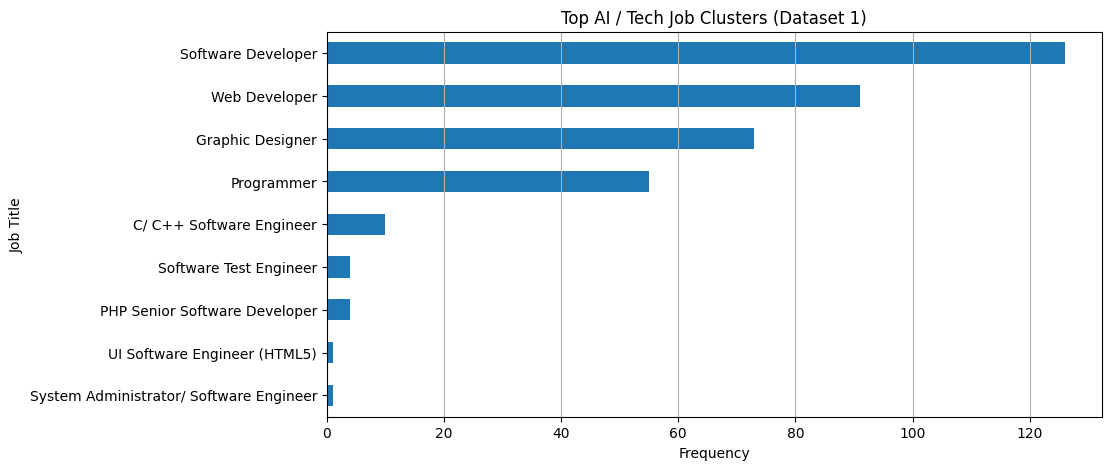

In [73]:
# =========================
# TOP AI / TECH JOB CLUSTERS
# =========================

top_job_clusters_1 = best_insight_df_1["title"].value_counts()

print("Top job clusters:")
display(top_job_clusters_1)

plt.figure(figsize=(10, 5))
top_job_clusters_1.sort_values().plot(kind="barh")
plt.xlabel("Frequency")
plt.ylabel("Job Title")
plt.title("Top AI / Tech Job Clusters (Dataset 1)")
plt.grid(axis="x")
plt.show()

###**e. Top companies**

Top companies:


,count
company,
Boomerang Software LLC,17
LTX-Credence Armenia LLC,8
SystroTech LLC,7
Haypost CJSC,7
McCann Erickson Armenia,6
Accept Employment Agency,6
SAS Group LLC,6
HSBC Bank Armenia CJSC,5
United Factors Group LLC,5


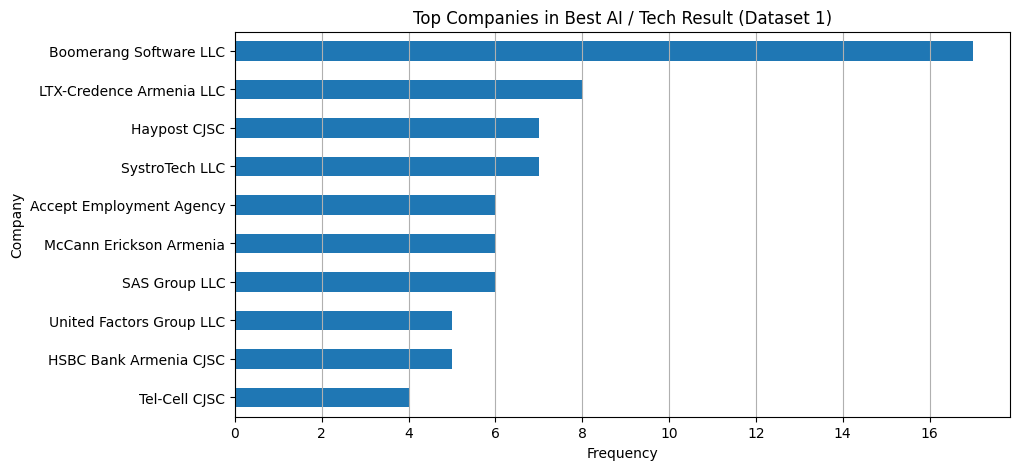

In [74]:
# =========================
# TOP COMPANIES
# =========================

top_companies_1 = best_insight_df_1["company"].replace("", "Unknown").value_counts().head(10)

print("Top companies:")
display(top_companies_1)

plt.figure(figsize=(10, 5))
top_companies_1.sort_values().plot(kind="barh")
plt.xlabel("Frequency")
plt.ylabel("Company")
plt.title("Top Companies in Best AI / Tech Result (Dataset 1)")
plt.grid(axis="x")
plt.show()

###**f. Top skill analysis**

In [75]:
# =========================
# SKILL FREQUENCY ANALYSIS
# =========================

skill_keywords_1 = {
    "machine learning": r"\bmachine learning\b",
    "deep learning": r"\bdeep learning\b",
    "artificial intelligence": r"\bartificial intelligence\b",
    "ai": r"\bai\b",
    "artificial intelligent": r"\bartificial intelligent\b",
    "statistics": r"\bstatistics\b",
    "communication": r"\bcommunication\b",
    "leadership": r"\bleadership\b",
    "research": r"\bresearch\b",
    "problem solving": r"\bproblem solving\b",
    "critical thinking": r"\bcritical thinking\b",
    "programming": r"\bprogramming\b",
    "data analysis": r"\bdata analysis\b",
    "data science": r"\bdata science\b",
    "analytics": r"\banalytics\b",
    "database": r"\bdatabase\b",
    "excel": r"\bexcel\b",
    "developer": r"\bdeveloper\b"
}

skill_counts = {}

for skill, pattern in skill_keywords_1.items():
    match_desc = best_insight_df_1["job_description"].str.contains(
        pattern, case=False, na=False, regex=True
    )

    match_skill = best_insight_df_1["job_requirement"].str.contains(
        pattern, case=False, na=False, regex=True
    )

    match_qual = best_insight_df_1["required_qual"].str.contains(
        pattern, case=False, na=False, regex=True
    )
    # OR condition
    count = (match_desc | match_skill | match_qual).sum()

    skill_counts[skill] = count

skill_counts = pd.Series(skill_counts).sort_values(ascending=False)

# just show if skill count > 0
skill_counts = skill_counts[skill_counts > 0]

print("Skill frequency (fixed):")
display(skill_counts)

Skill frequency (fixed):


,0
programming,153
developer,135
database,116
communication,87
problem solving,27
research,18
excel,3
analytics,2
statistics,1
critical thinking,1


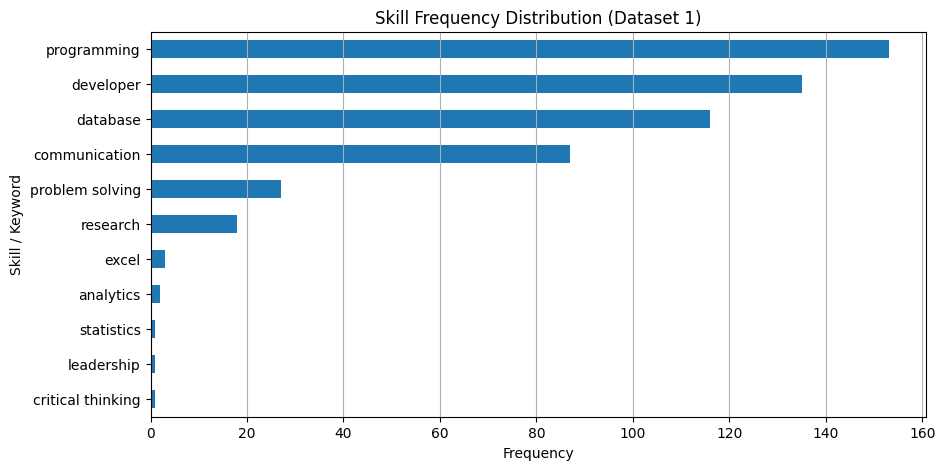

In [76]:
plt.figure(figsize=(10, 5))
skill_counts.sort_values().plot(kind="barh")
plt.xlabel("Frequency")
plt.ylabel("Skill / Keyword")
plt.title("Skill Frequency Distribution (Dataset 1)")
plt.grid(axis="x")
plt.show()

###**g. High-demand technologies**

In [77]:
# =========================
# HIGH-DEMAND TECHNOLOGIES
# =========================

tech_keywords_1 = {
    "python": r"\bpython\b",
    "sql": r"\bsql\b",
    "tensorflow": r"\btensorflow\b",
    "pytorch": r"\bpytorch\b",
    "scikit": r"\bscikit\b",
    "cloud": r"\bcloud\b",
    "aws": r"\baws\b",
    "azure": r"\bazure\b",
    "gcp": r"\bgcp\b",
    "spark": r"\bspark\b",
    "hadoop": r"\bhadoop\b",
    "dbt": r"\bdbt\b",
    "databricks": r"\bdatabricks\b",
    "c++": r"\bc++\b",
    "java": r"\bjava\b" ,
    "pandas": r"\bpandas\b",
    "numpy": r"\bnumpy\b",
    "cloud": r"\bcloud\b",
    "nlp": r"\bnlp\b|\bnatural language processing\b",
    "docker": r"\bdocker\b" ,
    "kubernetes": r"\bkubernetes\b",
    "linux": r"\blinux\b",
    "LLM": r"\bllm\b|\blarge language model(?:s)?\b",
    "CNN": r"\bcnn\b|\bconvolutional neural network(?:s)?\b",
    "ML frameworks": r"\bML frameworks\b"
}

tech_counts = {}

for tech, pattern in tech_keywords_1.items():

    match_desc = best_insight_df_1["job_description"].str.contains(
        pattern, case=False, na=False, regex=True
    )

    match_skill = best_insight_df_1["job_requirement"].str.contains(
        pattern, case=False, na=False, regex=True
    )
    match_qual = best_insight_df_1["required_qual"].str.contains(
        pattern, case=False, na=False, regex=True
    )
    count = (match_desc | match_skill | match_qual).sum()

    tech_counts[tech] = count

tech_counts = pd.Series(tech_counts).sort_values(ascending=False)

tech_counts = tech_counts[tech_counts > 0]

print("High-demand technologies:")
display(tech_counts)

High-demand technologies:


,0
c++,158
sql,144
java,60
linux,48
python,17


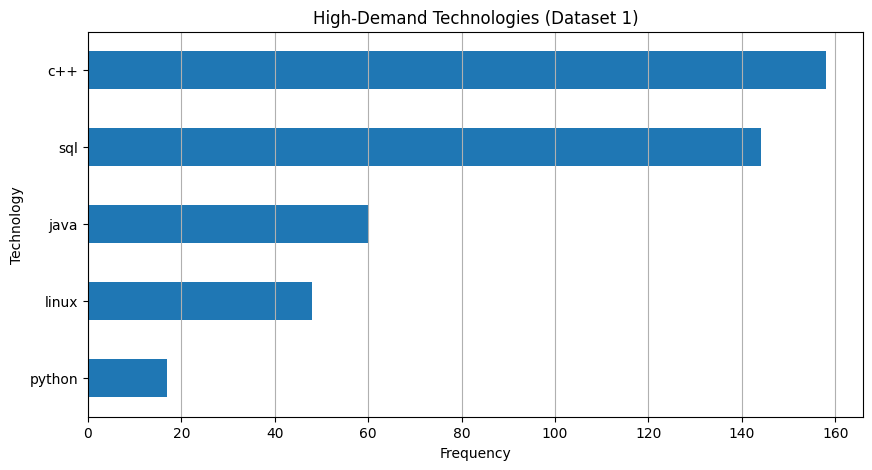

In [78]:
plt.figure(figsize=(10, 5))
tech_counts.sort_values().plot(kind="barh")
plt.xlabel("Frequency")
plt.ylabel("Technology")
plt.title("High-Demand Technologies (Dataset 1)")
plt.grid(axis="x")
plt.show()

###**h. Work type distribution**

Work type distribution:


,count
formatted_work_type,
Full time,290
Full-time,73
"Full time, additional employment negotiable",1
Full Time,1


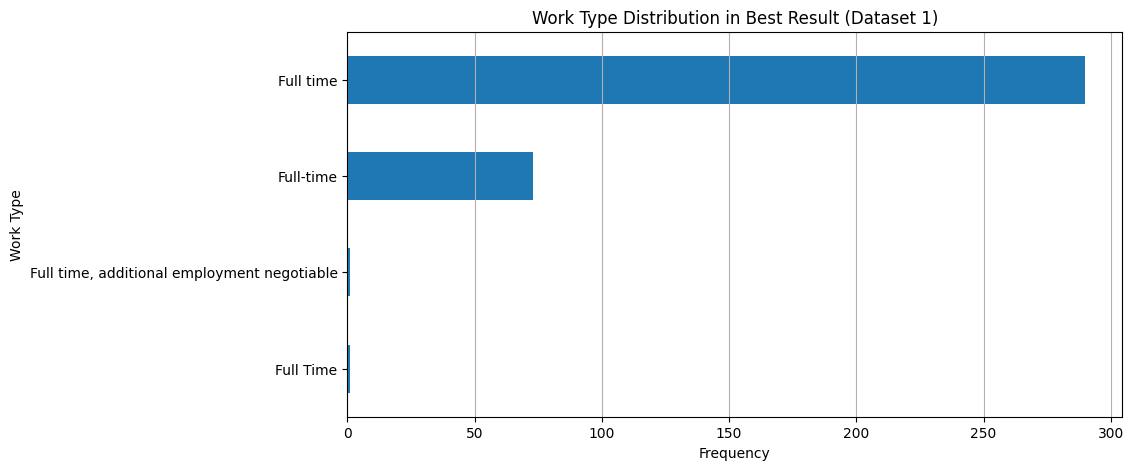

In [79]:
# =========================
# WORK TYPE DISTRIBUTION
# =========================

work_type_counts_1 = best_insight_df_1["formatted_work_type"].replace("", "Unknown").value_counts().head(10)

print("Work type distribution:")
display(work_type_counts_1)

plt.figure(figsize=(10, 5))
work_type_counts_1.sort_values().plot(kind="barh")
plt.xlabel("Frequency")
plt.ylabel("Work Type")
plt.title("Work Type Distribution in Best Result (Dataset 1)")
plt.grid(axis="x")
plt.show()

###**i. Experience distribution**

Experience distribution:


,count
formatted_experience_level,
All qualified candidates,276
All qualified and interested candidates.,73
"All Qualified candidates with eligibility\r\nto work in Yerevan, Armenia.",14
All persons with acceptable education\r\nand skills,1
"All Qualified candidates with eligibility\r\nto work in Yerevan, Armenia",1


) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


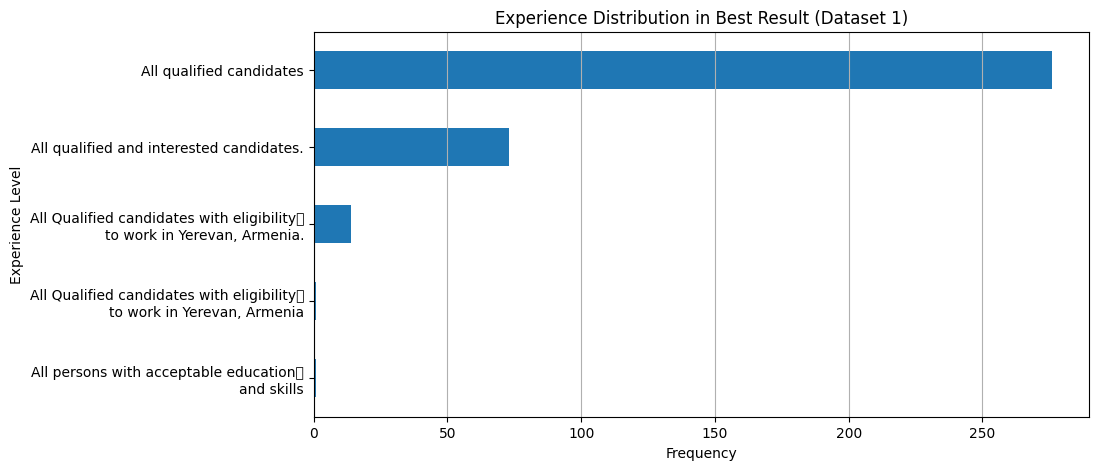

In [80]:
# =========================
# EXPERIENCE DISTRIBUTION
# =========================

experience_counts_1 = best_insight_df_1["formatted_experience_level"].replace("", "Unknown").value_counts().head(10)

print("Experience distribution:")
display(experience_counts_1)

plt.figure(figsize=(10, 5))
experience_counts_1.sort_values().plot(kind="barh")
plt.xlabel("Frequency")
plt.ylabel("Experience Level")
plt.title("Experience Distribution in Best Result (Dataset 1)")
plt.grid(axis="x")
plt.show()

###**j. Salary insight**

Salary summary in best result:


,salary_final
count,365.000000
mean,272986.301370
std,92774.613622
min,140000.000000
25%,200000.000000
50%,300000.000000
75%,375000.000000
max,400000.000000


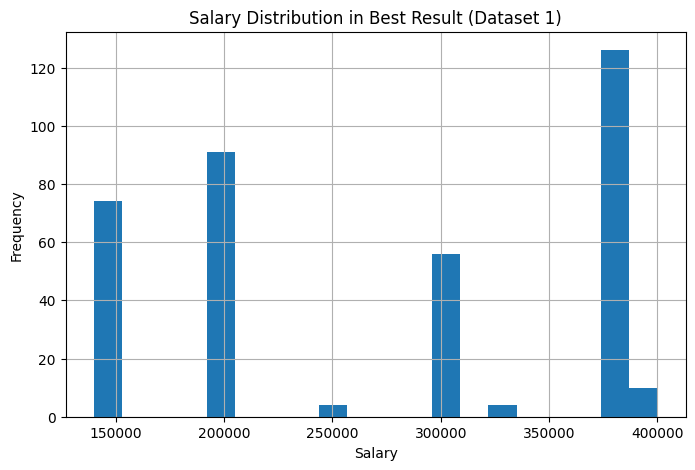

In [81]:
# =========================
# SALARY INSIGHT
# =========================

print("Salary summary in best result:")
display(best_insight_df_1["salary_final"].describe())

plt.figure(figsize=(8, 5))
best_insight_df_1["salary_final"].dropna().plot(kind="hist", bins=20)
plt.xlabel("Salary")
plt.title("Salary Distribution in Best Result (Dataset 1)")
plt.grid(True)
plt.show()

###**k. GA summary**

In [82]:
# =========================
# GA DESIGN SUMMARY
# =========================

ga_design_summary_1 = pd.DataFrame({
    "component": [
        "Encoding",
        "Fitness function",
        "Selection strategy",
        "Crossover operator",
        "Mutation operator",
        "Convergence behaviour"
    ],
    "description": [
        "Binary chromosome where each gene represents whether a filtering action is applied",
        "Balances AI/technical relevance, salary quality, salary availability, experience availability, location availability, full-time preference, and manageable result size",
        "Tournament selection",
        "Single-point crossover",
        "Bit-flip mutation with AI-related filter preserved",
        "Observed through best fitness over generations"
    ]
})

display(ga_design_summary_1)

,component,description
0,Encoding,Binary chromosome where each gene represents w...
1,Fitness function,"Balances AI/technical relevance, salary qualit..."
2,Selection strategy,Tournament selection
3,Crossover operator,Single-point crossover
4,Mutation operator,Bit-flip mutation with AI-related filter prese...
5,Convergence behaviour,Observed through best fitness over generations


###**l. GA convergence behaviour**

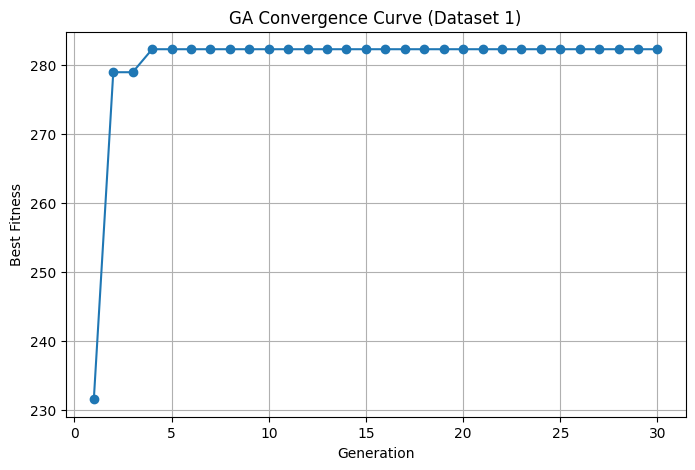

Initial fitness: 231.5169
Final fitness: 282.2467
Best fitness found: 282.2467
Best solution generation: 4


In [85]:
# =========================
# GA CONVERGENCE BEHAVIOUR
# =========================

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(ga_history_1_df) + 1), ga_history_1_df["best_fitness"], marker="o")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("GA Convergence Curve (Dataset 1)")
plt.grid(True)
plt.show()

print("Initial fitness:", ga_history_1_df["best_fitness"].iloc[0])
print("Final fitness:", ga_history_1_df["best_fitness"].iloc[-1])
print("Best fitness found:", ga_history_1_df["best_fitness"].max())
print("Best solution generation:", metrics_ga_1["convergence_generation"])

###**m. Trade-off summary**

In [86]:
# =========================
# TRADE-OFF SUMMARY TABLE
# =========================

tradeoff_summary_1 = pd.DataFrame({
    "algorithm": ["BFS", "A*", "GA"],
    "runtime_seconds": [
        summary_bfs_1_df.loc[0, "runtime_seconds"],
        summary_astar_1_df.loc[0, "runtime_seconds"],
        summary_ga_1_df.loc[0, "runtime_seconds"]
    ],
    "node_expansions": [
        summary_bfs_1_df.loc[0, "node_expansions"],
        summary_astar_1_df.loc[0, "node_expansions"],
        summary_ga_1_df.loc[0, "node_expansions"]
    ],
    "best_ranking_quality": [
        summary_bfs_1_df.loc[0, "best_ranking_quality"],
        summary_astar_1_df.loc[0, "best_ranking_quality"],
        summary_ga_1_df.loc[0, "best_ranking_quality"]
    ],
    "best_avg_salary": [
        summary_bfs_1_df.loc[0, "best_avg_salary"],
        summary_astar_1_df.loc[0, "best_avg_salary"],
        summary_ga_1_df.loc[0, "best_avg_salary"]
    ]
})

display(tradeoff_summary_1)

,algorithm,runtime_seconds,node_expansions,best_ranking_quality,best_avg_salary
0,BFS,44.5946,2094,89.03,400000.00
1,A*,47.6145,2094,89.03,400000.00
2,GA,41.9308,900,81.08,271111.11


##**2. Sample Dataset 2**

###**a. Copy best search: GA (full size)**

In [87]:
# =========================
# LOCK GA FULL SIZE OBJECTS FOR PART 5
# =========================

# Because the GA loop overwrites best_goal at each size,
# after the loop finishes, best_goal corresponds to the full size = 123849

best_goal_ga_123849 = results_summary_ga[123849]["best_goal"]
convergence_history_123849 = convergence_dict_ga[123849]

print("Best actions (GA full size):", best_goal_ga_123849["applied_actions"])
print("Best result shape (GA full size):", best_goal_ga_123849["result_df"].shape)

Best actions (GA full size): ['filter_ai_related', 'filter_salary_available', 'filter_experience_available', 'filter_work_type_full_time', 'filter_experience_senior', 'filter_salary_top_decile']
Best result shape (GA full size): (21, 15)


In [88]:
# =========================
# PART 5 - DATASET 2
# USE BEST RESULT FROM GA (full size)
# =========================

best_result_df_2 = best_goal_ga_123849["result_df"].copy()

assert "job_id" in best_result_df_2.columns, "Missing job_id — please rerun Part 4 with job_id included"

print("Best result shape:", best_result_df_2.shape)
print("Best actions:", best_goal_ga_123849["applied_actions"])
display(best_result_df_2.head())

Best result shape: (21, 15)
Best actions: ['filter_ai_related', 'filter_salary_available', 'filter_experience_available', 'filter_work_type_full_time', 'filter_experience_senior', 'filter_salary_top_decile']


,job_id,title,max_salary,location,min_salary,formatted_work_type,formatted_experience_level,normalized_salary,title_clean,location_clean,work_type_clean,experience_clean,salary_final,salary_available_flag,ai_title_flag
5349,3884992282,Sr. Manager Solutions Architecture - Generativ...,312800.0,"Seattle, WA",160800.0,Full-time,Mid-Senior level,236800.0,sr. manager solutions architecture - generativ...,"seattle, wa",full-time,mid-senior level,236800.0,True,True
12111,3887576711,Principal AI/ML Data Scientist,322100.0,"San Francisco, CA",173400.0,Full-time,Mid-Senior level,247750.0,principal ai/ml data scientist,"san francisco, ca",full-time,mid-senior level,247750.0,True,True
18539,3888939625,"Modeling, Simulation & Training AI Solution Ar...",260850.0,"Orlando, FL",144300.0,Full-time,Mid-Senior level,202575.0,"modeling, simulation & training ai solution ar...","orlando, fl",full-time,mid-senior level,202575.0,True,True
19925,3889121407,"Senior Software Engineer, AI Developer Tools -...",339250.0,United States,180000.0,Full-time,Mid-Senior level,259625.0,"senior software engineer, ai developer tools -...",united states,full-time,mid-senior level,259625.0,True,True
19933,3889121579,"Senior Distributed Systems Engineer, AI Infras...",276000.0,"Santa Clara, CA",148000.0,Full-time,Mid-Senior level,212000.0,"senior distributed systems engineer, ai infras...","santa clara, ca",full-time,mid-senior level,212000.0,True,True


###**b. Load extra columns**

In [89]:
# =========================
# LOAD EXTRA COLUMNS (PART 5)
# =========================
def load_dataset_2_part5_extra(file_path, nrows=123849):
    cols = [
        "job_id",
        "company_name",
        "description",
        "skills_desc",
        "remote_allowed"
    ]

    df = pd.read_csv(file_path, usecols=cols, nrows=nrows)

    # clean text
    for col in ["company_name", "description", "skills_desc"]:
        df[col] = df[col].fillna("").astype(str).str.strip()

    df["remote_allowed"] = df["remote_allowed"].fillna(False)

    return df


dataset2_part5_df = load_dataset_2_part5_extra(file_path, nrows=123849)

print("Extra data shape:", dataset2_part5_df.shape)
display(dataset2_part5_df.head())

Extra data shape: (123849, 5)


,job_id,company_name,description,remote_allowed,skills_desc
0,921716,Corcoran Sawyer Smith,Job descriptionA leading real estate firm in N...,False,Requirements: \n\nWe are seeking a College or ...
1,1829192,,"At Aspen Therapy and Wellness , we are committ...",False,
2,10998357,The National Exemplar,The National Exemplar is accepting application...,False,We are currently accepting resumes for FOH - A...
3,23221523,"Abrams Fensterman, LLP",Senior Associate Attorney - Elder Law / Trusts...,False,This position requires a baseline understandin...
4,35982263,,Looking for HVAC service tech with experience ...,False,


###**c. Merge best search result with extra columns**

In [90]:
# =========================
# MERGE USING JOB_ID
# =========================

extra_text_df_2 = dataset2_part5_df[
    ["job_id", "company_name", "description", "skills_desc", "remote_allowed"]
].drop_duplicates()

best_insight_df_2 = best_result_df_2.merge(
    extra_text_df_2,
    on="job_id",
    how="left"
)

best_insight_df_2 = best_insight_df_2.drop_duplicates()

print("Merged shape:", best_insight_df_2.shape)
display(best_insight_df_2.head())

Merged shape: (21, 19)


,job_id,title,max_salary,location,min_salary,formatted_work_type,formatted_experience_level,normalized_salary,title_clean,location_clean,work_type_clean,experience_clean,salary_final,salary_available_flag,ai_title_flag,company_name,description,skills_desc,remote_allowed
0,3884992282,Sr. Manager Solutions Architecture - Generativ...,312800.0,"Seattle, WA",160800.0,Full-time,Mid-Senior level,236800.0,sr. manager solutions architecture - generativ...,"seattle, wa",full-time,mid-senior level,236800.0,True,True,Amazon Web Services (AWS),Description\n\nDo you like startups? Are you i...,,False
1,3887576711,Principal AI/ML Data Scientist,322100.0,"San Francisco, CA",173400.0,Full-time,Mid-Senior level,247750.0,principal ai/ml data scientist,"san francisco, ca",full-time,mid-senior level,247750.0,True,True,Cisco ThousandEyes,Who We Are\n\nThe name ThousandEyes was born f...,,False
2,3888939625,"Modeling, Simulation & Training AI Solution Ar...",260850.0,"Orlando, FL",144300.0,Full-time,Mid-Senior level,202575.0,"modeling, simulation & training ai solution ar...","orlando, fl",full-time,mid-senior level,202575.0,True,True,Leidos,Description\n\nLeidos is seeking a Solutions A...,,False
3,3889121407,"Senior Software Engineer, AI Developer Tools -...",339250.0,United States,180000.0,Full-time,Mid-Senior level,259625.0,"senior software engineer, ai developer tools -...",united states,full-time,mid-senior level,259625.0,True,True,NVIDIA,NVIDIA has been transforming computer graphics...,,1.0
4,3889121579,"Senior Distributed Systems Engineer, AI Infras...",276000.0,"Santa Clara, CA",148000.0,Full-time,Mid-Senior level,212000.0,"senior distributed systems engineer, ai infras...","santa clara, ca",full-time,mid-senior level,212000.0,True,True,NVIDIA,NVIDIA is hiring senior distributed systems en...,,False


###**d. Top AI-related job clusters**

In [91]:
# =========================
# TOP AI-RELATED JOB CLUSTERS
# =========================

top_job_clusters_2 = best_insight_df_2["title"].value_counts()

print("Top job clusters:")
display(top_job_clusters_2)

Top job clusters:


,count
title,
"Sr. Manager Solutions Architecture - Generative AI, AWS Startups",1
Principal AI/ML Data Scientist,1
"Modeling, Simulation & Training AI Solution Architect",1
"Senior Software Engineer, AI Developer Tools - Cloud Software",1
"Senior Distributed Systems Engineer, AI Infrastructure",1
Senior Product Manager - DDoS & AI,1
Corporate Counsel - Global Generative AI Company,1
Data Scientist - AI Investment,1
"Principal Product Manager, Confluence AI",1


###**e. Top companies**

Top companies:


,count
company_name,
Amazon Web Services (AWS),3
NVIDIA,2
Amazon,2
Leidos,1
Cisco ThousandEyes,1
Larson Maddox,1
Burton Recruitment Limited,1
Atlassian,1
Fruition IT,1


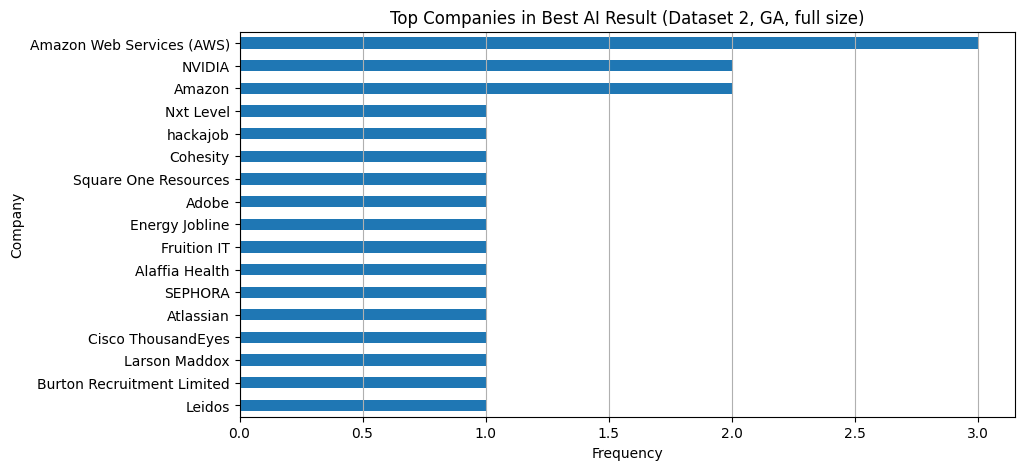

In [92]:
# =========================
# TOP COMPANIES
# =========================

top_companies_2 = best_insight_df_2["company_name"].replace("", "Unknown").value_counts()

print("Top companies:")
display(top_companies_2)

plt.figure(figsize=(10, 5))
top_companies_2.sort_values().plot(kind="barh")
plt.title("Top Companies in Best AI Result (Dataset 2, GA, full size)")
plt.xlabel("Frequency")
plt.ylabel("Company")
plt.grid(axis="x")
plt.show()

###**f. Skill frequency analysis**

In [93]:
# =========================
# SKILL FREQUENCY ANALYSIS
# =========================

skill_keywords_2 = {
    "machine learning": r"\bmachine learning\b",
    "deep learning": r"\bdeep learning\b",
    "artificial intelligence": r"\bartificial intelligence\b",
    "ai": r"\bai\b",
    "artificial intelligent": r"\bartificial intelligent\b",
    "statistics": r"\bstatistics\b",
    "communication": r"\bcommunication\b",
    "leadership": r"\bleadership\b",
    "research": r"\bresearch\b",
    "problem solving": r"\bproblem solving\b",
    "critical thinking": r"\bcritical thinking\b",
    "programming": r"\bprogramming\b",
    "data analysis": r"\bdata analysis\b",
    "data science": r"\bdata science\b",
    "analytics": r"\banalytics\b",
    "database": r"\bdatabase\b",
    "excel": r"\bexcel\b",
    "developer": r"\bdeveloper\b"
}

skill_counts = {}

for skill, pattern in skill_keywords_2.items():
    match_desc = best_insight_df_2["description"].str.contains(
        pattern, case=False, na=False, regex=True
    )

    match_skill = best_insight_df_2["skills_desc"].str.contains(
        pattern, case=False, na=False, regex=True
    )

    # OR condition
    count = (match_desc | match_skill).sum()

    skill_counts[skill] = count # Added this line to populate the dictionary

skill_counts = pd.Series(skill_counts).sort_values(ascending=False)

# Just show skill frequency > 0
skill_counts = skill_counts[skill_counts > 0]

print("Skill frequency:")
display(skill_counts)


Skill frequency:


,0
ai,20
machine learning,13
leadership,12
communication,9
programming,9
research,8
deep learning,7
artificial intelligence,7
analytics,6
data science,4


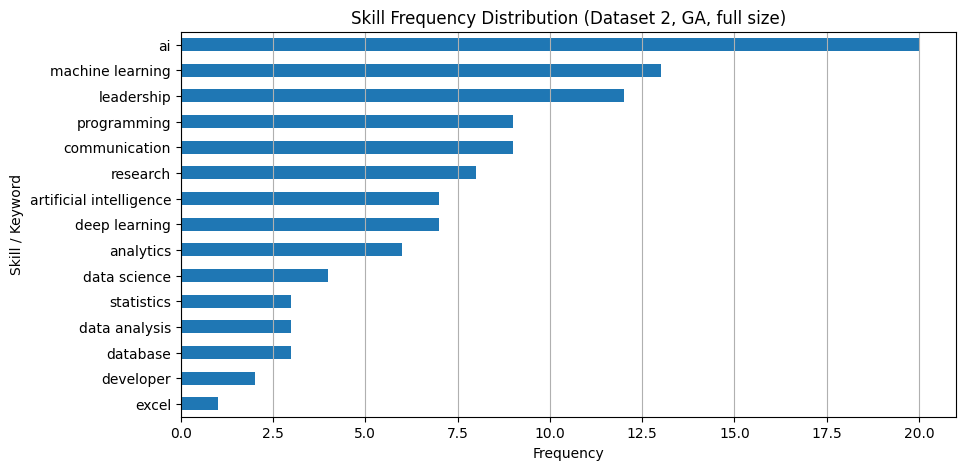

In [94]:
plt.figure(figsize=(10, 5))
skill_counts.sort_values().plot(kind="barh")
plt.xlabel("Frequency")
plt.ylabel("Skill / Keyword")
plt.title("Skill Frequency Distribution (Dataset 2, GA, full size)")
plt.grid(axis="x")
plt.show()

###**g. High-demand technologies**

In [95]:
# =========================
# HIGH-DEMAND TECHNOLOGIES
# =========================

tech_keywords_2 = {
    "python": r"\bpython\b",
    "sql": r"\bsql\b",
    "tensorflow": r"\btensorflow\b",
    "pytorch": r"\bpytorch\b",
    "scikit": r"\bscikit\b",
    "cloud": r"\bcloud\b",
    "aws": r"\baws\b",
    "azure": r"\bazure\b",
    "gcp": r"\bgcp\b",
    "spark": r"\bspark\b",
    "hadoop": r"\bhadoop\b",
    "dbt": r"\bdbt\b",
    "databricks": r"\bdatabricks\b",
    "c++": r"\bc++\b",
    "java": r"\bjava\b" ,
    "pandas": r"\bpandas\b",
    "numpy": r"\bnumpy\b",
    "cloud": r"\bcloud\b",
    "nlp": r"\bnlp\b|\bnatural language processing\b",
    "docker": r"\bdocker\b" ,
    "kubernetes": r"\bkubernetes\b",
    "linux": r"\blinux\b",
    "LLM": r"\bllm\b|\blarge language model(?:s)?\b",
    "CNN": r"\bcnn\b|\bconvolutional neural network(?:s)?\b",
    "ML frameworks": r"\bML frameworks\b"
}

tech_counts = {}

for tech, pattern in tech_keywords_2.items():

    match_desc = best_insight_df_2["description"].str.contains(
        pattern, case=False, na=False, regex=True
    )

    match_skill = best_insight_df_2["skills_desc"].str.contains(
        pattern, case=False, na=False, regex=True
    )

    count = (match_desc | match_skill).sum()

    tech_counts[tech] = count

tech_counts = pd.Series(tech_counts).sort_values(ascending=False)

tech_counts = tech_counts[tech_counts > 0]

print("High-demand technologies:")
display(tech_counts)

High-demand technologies:


,0
python,12
cloud,10
aws,7
tensorflow,7
LLM,7
c++,7
pytorch,6
spark,6
hadoop,5
java,5


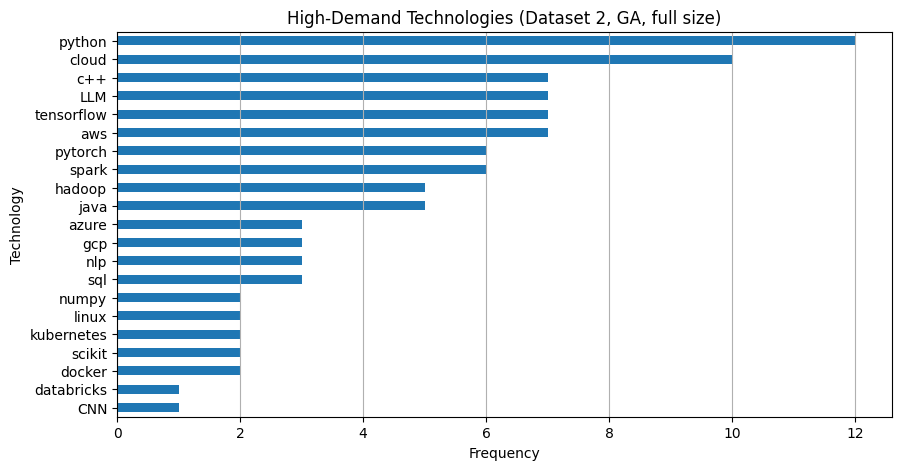

In [96]:
plt.figure(figsize=(10, 5))
tech_counts.sort_values().plot(kind="barh")
plt.xlabel("Frequency")
plt.ylabel("Technology")
plt.title("High-Demand Technologies (Dataset 2, GA, full size)")
plt.grid(axis="x")
plt.show()

###**h. Work type distribution**

Work type distribution:


,count
formatted_work_type,
Full-time,21


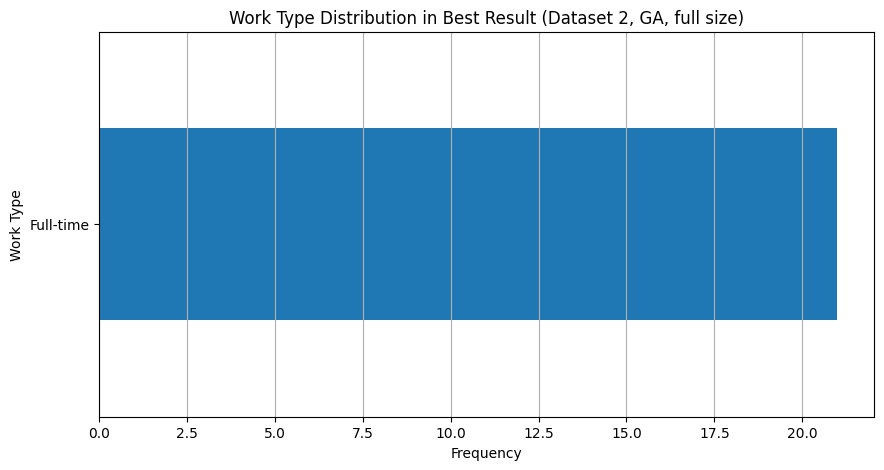

In [97]:
# =========================
# WORK TYPE DISTRIBUTION
# =========================
work_type_counts_2 = best_insight_df_2["formatted_work_type"].value_counts().head(10)

print("Work type distribution:")
display(work_type_counts_2)

plt.figure(figsize=(10, 5))
work_type_counts_2.sort_values().plot(kind="barh")
plt.xlabel("Frequency")
plt.ylabel("Work Type")
plt.title("Work Type Distribution in Best Result (Dataset 2, GA, full size)")
plt.grid(axis="x")
plt.show()

###**i. Experience distribution**

Experience distribution:


,count
formatted_experience_level,
Mid-Senior level,21


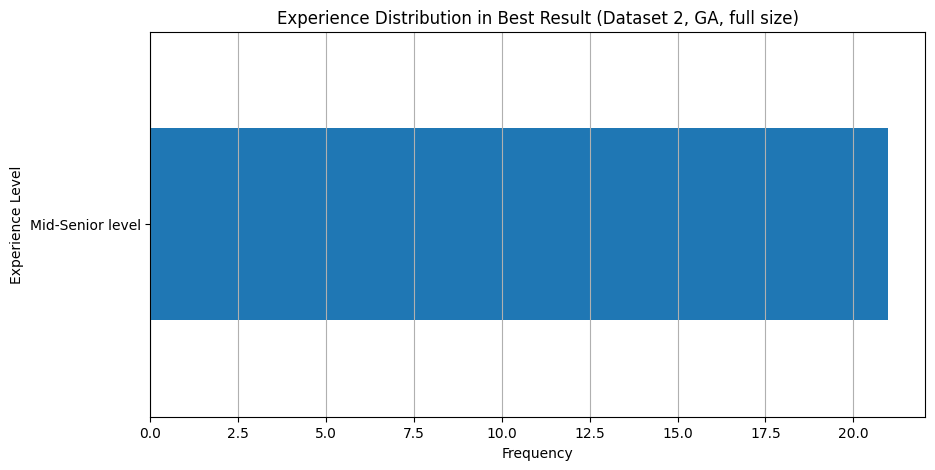

In [98]:
# =========================
# EXPERIENCE DISTRIBUTION
# =========================
experience_counts_2 = best_insight_df_2["formatted_experience_level"].value_counts()

print("Experience distribution:")
display(experience_counts_2)

plt.figure(figsize=(10, 5))
experience_counts_2.sort_values().plot(kind="barh")
plt.xlabel("Frequency")
plt.ylabel("Experience Level")
plt.title("Experience Distribution in Best Result (Dataset 2, GA, full size)")
plt.grid(axis="x")
plt.show()

###**j. Salary insight**

Salary summary in best result:


,salary_final
count,21.000000
mean,209031.904762
std,29254.671229
min,170000.000000
25%,182100.000000
50%,204450.000000
75%,225000.000000
max,262500.000000


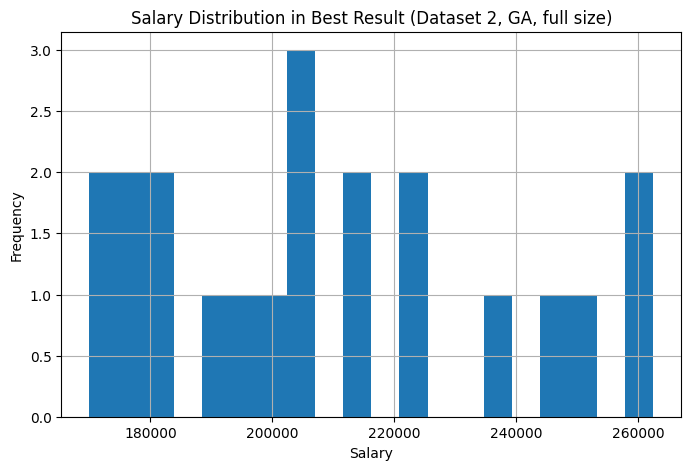

In [99]:
# =========================
# SALARY INSIGHT
# =========================
print("Salary summary in best result:")
display(best_insight_df_2["salary_final"].describe())

plt.figure(figsize=(8, 5))
best_result_df_2["salary_final"].dropna().plot(kind="hist", bins=20)
plt.xlabel("Salary")
plt.title("Salary Distribution in Best Result (Dataset 2, GA, full size)")
plt.grid(True)
plt.show()

###**k. GA summary**

In [100]:
# =========================
# GA DESIGN SUMMARY
# =========================
ga_design_summary_2 = pd.DataFrame({
    "component": [
        "Encoding",
        "Fitness function",
        "Selection strategy",
        "Crossover operator",
        "Mutation operator",
        "Convergence behaviour"
    ],
    "description": [
        "Binary chromosome where each gene represents whether a filtering action is applied",
        "Balances AI relevance, salary quality, salary availability, experience availability, location availability, full-time preference, and manageable result size",
        "Tournament selection",
        "Single-point crossover",
        "Bit-flip mutation with AI-related filter preserved",
        "Observed through best fitness over generations"
    ]
})

display(ga_design_summary_2)

,component,description
0,Encoding,Binary chromosome where each gene represents w...
1,Fitness function,"Balances AI relevance, salary quality, salary ..."
2,Selection strategy,Tournament selection
3,Crossover operator,Single-point crossover
4,Mutation operator,Bit-flip mutation with AI-related filter prese...
5,Convergence behaviour,Observed through best fitness over generations


###**l. GA convergence behaviour**

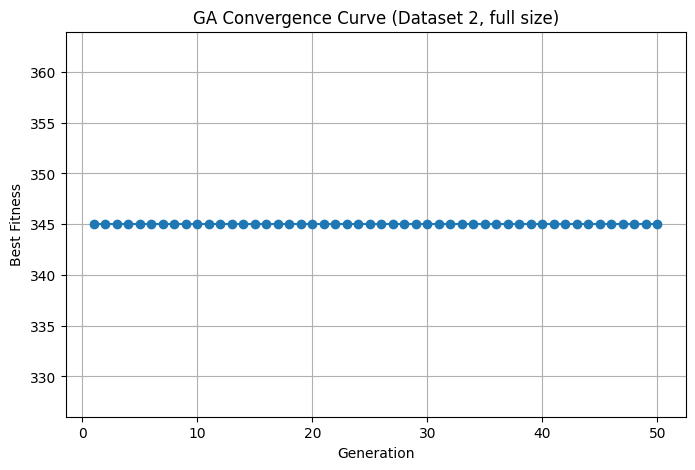

Initial fitness: 345.0
Final fitness: 345.0
Best fitness found: 345.0
Convergence generation: 2


In [103]:
# =========================
# GA CONVERGENCE BEHAVIOUR
# =========================
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(convergence_history_123849) + 1), convergence_history_123849["best_fitness"], marker="o")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("GA Convergence Curve (Dataset 2, full size)")
plt.grid(True)
plt.show()

print("Initial fitness:", convergence_history_123849["best_fitness"].iloc[0])
print("Final fitness:", convergence_history_123849["best_fitness"].iloc[-1])
print("Best fitness found:", convergence_history_123849["best_fitness"].max())
print("Convergence generation:", best_goal_ga_123849["generation"])

###**m. Trade-off summary**

In [102]:
# =========================
# TRADE-OFF SUMMARY TABLE
# =========================
bfs_fullsize = summary_bfs_df[summary_bfs_df["dataset_size"] == 123849].iloc[0]
astar_fullsize = summary_astar_df[summary_astar_df["dataset_size"] == 123849].iloc[0]
ga_fullsize = summary_ga_df[summary_ga_df["dataset_size"] == 123849].iloc[0]

tradeoff_summary_2 = pd.DataFrame({
    "algorithm": ["BFS", "A*", "GA"],
    "runtime_seconds": [
        bfs_fullsize["runtime_seconds"],
        astar_fullsize["runtime_seconds"],
        ga_fullsize["runtime_seconds"]
    ],
    "node_expansions": [
        bfs_fullsize["node_expansions"],
        astar_fullsize["node_expansions"],
        ga_fullsize["node_expansions"]
    ],
    "best_ranking_quality": [
        bfs_fullsize["best_ranking_quality"],
        astar_fullsize["best_ranking_quality"],
        ga_fullsize["best_ranking_quality"]
    ],
    "best_avg_salary": [
        bfs_fullsize["best_avg_salary"],
        astar_fullsize["best_avg_salary"],
        ga_fullsize["best_avg_salary"]
    ]
})

display(tradeoff_summary_2)

,algorithm,runtime_seconds,node_expansions,best_ranking_quality,best_avg_salary
0,BFS,434.5027,4415,100.0,220117.5
1,A*,522.1535,4415,100.0,220117.5
2,GA,79.1382,1500,100.0,209031.9
